In [3]:
!pip install pandas numpy geopy scikit-learn

In [2]:
import pandas as pd
import numpy as np
from geopy.distance import geodesic
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("../../datasets/normalized_data/combined_normalized.csv")

In [4]:
df

,Transacted Price ($),Area (SQFT),Unit Price ($ PSF),Dist to CBD in Km,Sale Months Since Sep 2025,Num MRT Within 1km,Num Hawker Within 1km,Num Malls Within 1km,Num Hospitals Within 5km,Num Schools Within 2km,Num Parks Within 1km,Floor_Level_Category,Type_of_Sale_Encoded,Property_Type_Encoded,Market_Segment_Encoded,District
0,-0.211237,-0.460443,0.774350,1.347678,-1.117103,-1.177227,-1.175060,-1.296450,-1.143547,-1.118512,-1.374335,-1.619747,-1.228179,-0.334688,1.124971,1
1,-0.087630,-0.460443,1.240198,1.347678,-1.117103,-1.177227,-1.175060,-1.296450,-1.143547,-1.118512,-1.374335,0.947931,-1.228179,-0.334688,1.124971,1
2,-0.303362,-0.331436,-0.058154,-0.618881,-1.117103,-0.723616,-0.407922,0.640686,0.276567,-0.286674,0.161507,-0.152502,0.814214,2.987854,-0.888912,1
3,-0.100129,-0.442004,1.103809,1.347678,-1.117103,-1.177227,-1.175060,-1.296450,-1.143547,-1.118512,-1.374335,0.214309,-1.228179,-0.334688,1.124971,1
4,1.493910,2.267081,-0.950882,-0.363513,-1.117103,0.183604,-0.407922,0.156402,-0.670176,-0.286674,-0.030473,-1.619747,0.814214,-0.334688,-0.888912,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108367,0.046775,0.568074,-0.689954,-0.705343,1.573169,-0.762994,-0.374606,-1.216935,-1.442506,-1.156276,0.444833,1.136026,0.794933,0.657310,0.080720,28
108368,-0.016193,0.688792,-0.856036,-0.313104,1.573169,-0.287893,-0.374606,0.110836,0.451368,-0.384110,2.193072,-1.058519,0.794933,0.657310,0.080720,28
108369,-0.769843,1.443211,-1.977090,-0.350310,1.573169,-0.287893,-0.374606,-0.553049,0.451368,0.388056,-0.254463,-1.058519,0.794933,0.657310,0.080720,28
108370,0.656779,1.865669,-1.053869,-1.312109,1.573169,-1.238095,-0.374606,-1.216935,0.451368,-1.156276,-0.604110,-1.058519,0.794933,0.657310,-12.388450,28


## Simple Linear Regression

In [16]:
# --- single_feature_cv_metrics.py ---
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

# CONFIG
target_col = 'Transacted Price ($)'
feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded'
]
# keep only existing columns
feature_cols = [f for f in feature_cols if f in df.columns]

CV_FOLDS = 5
RANDOM_STATE = 42
MIN_ROWS = 30    # skip feature if below this many rows after dropna
EPS = 1e-6       # avoid zero division in MAPE

def safe_mape(y_true, y_pred):
    # clip true values to avoid division by zero
    return mean_absolute_percentage_error(np.maximum(y_true, EPS), y_pred)

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        'r2_full': r2_score(y_true, y_pred),
        'rmse_full': mean_squared_error(y_true, y_pred, squared=False),
        'mae_full': mean_absolute_error(y_true, y_pred),
        'mape_full': safe_mape(y_true, y_pred)
    }

rows = []
for feature in feature_cols:
    sub = df[[feature, target_col]].dropna().copy()
    n = len(sub)
    if n < MIN_ROWS:
        print(f"Skipping '{feature}' — only {n} rows (< {MIN_ROWS})")
        continue

    # ensure numeric values
    try:
        X_full = sub[feature].astype(float).values.reshape(-1, 1)
        y_full = sub[target_col].astype(float).values
    except Exception as e:
        print(f"Skipping '{feature}' — conversion to float failed: {e}")
        continue

    # Fit on full data
    lr = LinearRegression()
    lr.fit(X_full, y_full)
    y_full_pred = lr.predict(X_full)
    full_metrics = compute_metrics(y_full, y_full_pred)

    # Cross-validated metrics
    # choose folds = min(CV_FOLDS, n) but require at least 2 folds
    n_splits = min(CV_FOLDS, n) if n >= 2 else 2
    # if too few samples for requested folds, reduce folds
    if n_splits < 2:
        print(f"Skipping CV for '{feature}' — insufficient samples: n={n}")
        continue

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    cv_r2_list = []
    cv_rmse_list = []
    cv_mae_list = []
    cv_mape_list = []
    folds_used = 0

    for train_idx, val_idx in kf.split(X_full):
        X_tr, X_val = X_full[train_idx], X_full[val_idx]
        y_tr, y_val = y_full[train_idx], y_full[val_idx]

        # if y_tr is constant, r2 undefined in fold — still try; but skip if degenerate
        if np.unique(y_tr).size < 2:
            continue

        model = LinearRegression()
        model.fit(X_tr, y_tr)
        y_val_pred = model.predict(X_val)

        cv_r2_list.append(r2_score(y_val, y_val_pred))
        cv_rmse_list.append(mean_squared_error(y_val, y_val_pred, squared=False))
        cv_mae_list.append(mean_absolute_error(y_val, y_val_pred))
        cv_mape_list.append(safe_mape(y_val, y_val_pred))
        folds_used += 1

    if folds_used == 0:
        print(f"No valid CV folds for '{feature}' (n={n}). Skipping feature.")
        continue

    row = {
        'feature': feature,
        'n': n,
        # full-sample
        'r2_full': full_metrics['r2_full'],
        'rmse_full': full_metrics['rmse_full'],
        'mae_full': full_metrics['mae_full'],
        'mape_full': full_metrics['mape_full'],
        # CV averages
        'cv_r2_mean': np.mean(cv_r2_list),
        'cv_r2_std': np.std(cv_r2_list),
        'cv_rmse_mean': np.mean(cv_rmse_list),
        'cv_mae_mean': np.mean(cv_mae_list),
        'cv_mape_mean': np.mean(cv_mape_list),
        'cv_folds_used': folds_used
    }
    rows.append(row)

results_df = pd.DataFrame(rows)
if results_df.empty:
    print("No features produced valid results. Check data and MIN_ROWS.")
else:
    # sort by cv_r2_mean descending
    results_df = results_df.sort_values('cv_r2_mean', ascending=False).reset_index(drop=True)

    # print results nicely
    pd.set_option('display.float_format', lambda x: f"{x:0.4f}")
    print("\n=== Single-feature linear regression results (sorted by CV R² mean) ===\n")
    display_cols = ['feature','n','r2_full','cv_r2_mean','cv_r2_std','cv_rmse_mean','cv_mae_mean','cv_mape_mean']
    print(results_df[display_cols].to_string(index=False))

    # best feature
    best = results_df.iloc[0]
    print("\n" + "="*60)
    print(f"Best feature: {best['feature']}")
    print(f"Samples: {int(best['n'])}")
    print(f"Full R² = {best['r2_full']:.4f}")
    print(f"CV R² mean = {best['cv_r2_mean']:.4f} (std {best['cv_r2_std']:.4f})")
    print(f"CV RMSE = {best['cv_rmse_mean']:.2f}, CV MAE = {best['cv_mae_mean']:.2f}, CV MAPE = {best['cv_mape_mean']:.4f}")
    print("="*60)

    # save to csv if desired
    results_df.to_csv("single_feature_cv_summary.csv", index=False)
    print("\nSaved summary to 'single_feature_cv_summary.csv'")



=== Single-feature linear regression results (sorted by CV R² mean) ===

                   feature      n  r2_full  cv_r2_mean  cv_r2_std  cv_rmse_mean  cv_mae_mean  cv_mape_mean
Sale Months Since Sep 2025 108372   0.0451      0.0467     0.0094        0.9780       0.6445   110845.2300
      Type_of_Sale_Encoded 108372   0.0364      0.0377     0.0076        0.9826       0.6509   100633.2934
      Floor_Level_Category 108372   0.0118      0.0119     0.0012        0.9954       0.6585    51541.7257
    Market_Segment_Encoded 108372   0.0062      0.0063     0.0010        0.9982       0.6602    22882.3286
  Num Hospitals Within 5km 108372   0.0043      0.0043     0.0005        0.9992       0.6603    29665.7735
         Dist to CBD in Km 108372   0.0033      0.0034     0.0006        0.9997       0.6604    27884.6035
     Property_Type_Encoded 108372   0.0009      0.0009     0.0005        1.0009       0.6613    15887.2656
     Num Hawker Within 1km 108372   0.0007      0.0007     0.0003     

## Simple Linear Regression by District

In [15]:
# --- Imports ---
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# --- Config ---
target_col = 'Transacted Price ($)'
feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded'
]

# --- Ensure required columns exist ---
for col in [target_col, 'District']:
    if col not in df.columns:
        raise KeyError(f"Missing column: {col}")

districts = sorted(df['District'].dropna().unique().astype(int))

# --- Container for results ---
district_results = []

# --- Step 1: Loop over districts ---
for dist in districts:
    df_dist = df[df['District'] == dist].copy()
    if len(df_dist) < 50:  # skip small districts with too few data points
        continue

    print(f"\n=== District {dist} (n={len(df_dist)}) ===")

    results = []
    for feature in feature_cols:
        subset = df_dist[[feature, target_col]].dropna()
        if subset.empty:
            continue
        X = subset[[feature]]
        y = subset[target_col]

        model = LinearRegression()
        model.fit(X, y)
        y_pred = model.predict(X)

        coef = model.coef_[0]
        r2 = r2_score(y, y_pred)

        results.append((feature, coef, r2))

    if not results:
        continue

    # Sort by R²
    results_df = (
        pd.DataFrame(results, columns=['Feature', 'Coefficient', 'R²'])
        .sort_values('R²', ascending=False)
        .reset_index(drop=True)
    )

    # Append to master list
    for _, row in results_df.iterrows():
        district_results.append({
            'District': dist,
            'Feature': row['Feature'],
            'Coefficient': row['Coefficient'],
            'R²': row['R²']
        })

    # Display top features for this district
    print("Top features by R²:\n", results_df.head(5), "\n")

# --- Step 2: Combine all district results ---
all_results_df = pd.DataFrame(district_results)

# Sort by district and then by R² descending
all_results_df = all_results_df.sort_values(['District', 'R²'], ascending=[True, False]).reset_index(drop=True)

# --- Step 3: Display summary ---
print("\n===== Summary of Feature Impact by District (Sorted by R²) =====\n")
print(all_results_df.head(30))  # preview top 30 rows

# --- Optional: Save to CSV for reporting ---
all_results_df.to_csv("district_feature_r2_summary.csv", index=False)
print("\nResults saved to 'district_feature_r2_summary.csv'")



=== District 1 (n=1638) ===
Top features by R²:
                       Feature  Coefficient        R²
0       Property_Type_Encoded     0.222569  0.049537
1        Floor_Level_Category     0.191947  0.036844
2      Market_Segment_Encoded    -0.114068  0.013012
3  Sale Months Since Sep 2025     0.082988  0.006887
4           Dist to CBD in Km    -0.078734  0.006199 


=== District 2 (n=1207) ===
Top features by R²:
                  Feature  Coefficient        R²
0   Floor_Level_Category     0.304769  0.091825
1   Num Malls Within 1km     0.299123  0.088130
2   Num Parks Within 1km     0.278287  0.077579
3  Num Hawker Within 1km     0.256005  0.065306
4     Num MRT Within 1km     0.249368  0.061074 


=== District 3 (n=4625) ===
Top features by R²:
                   Feature  Coefficient        R²
0  Num Schools Within 2km     0.374077  0.140932
1    Num Parks Within 1km     0.310704  0.093896
2    Type_of_Sale_Encoded    -0.260399  0.065975
3   Num Hawker Within 1km    -0.203794  0.04

## Multiple Linear Regression

#### 2 Features Combination between different amenities

In [ ]:
import itertools
import pandas as pd
import statsmodels.api as sm

# --- Configuration ---
target_col = 'Transacted Price ($)'

# Amenity-type independent variables
amenities = [
    'Num MRT Within 1km',
    'Num Schools Within 2km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Parks Within 1km'
]

# --- Helper: Run regression and extract results ---
def run_ols(df, features, target):
    """Run OLS regression for a given feature set and return metrics"""
    subset = df[features + [target]].dropna()
    X = sm.add_constant(subset[features].astype(float), has_constant='add')
    y = subset[target].astype(float)

    model = sm.OLS(y, X).fit()
    sig_feats = model.pvalues[model.pvalues < 0.05].drop('const', errors='ignore').index.tolist()
    
    return {
        'features': features,
        'n': len(subset),
        'r2': model.rsquared,
        'adj_r2': model.rsquared_adj,
        'sig_features': sig_feats,
        'pvalues': model.pvalues.to_dict(),
        'params': model.params.to_dict()
    }

# --- Run pairwise (2-feature) combinations ---
results = []
for combo in itertools.combinations(amenities, 2):
    res = run_ols(df, list(combo), target_col)
    # keep only models with at least one significant feature
    if len(res['sig_features']) > 0:
        results.append(res)

# --- Convert to DataFrame ---
results_df = pd.DataFrame(results)
if not results_df.empty:
    results_df = results_df.sort_values('adj_r2', ascending=False).reset_index(drop=True)

    print(f"\n===== Significant 2-feature Models (p < 0.05) =====\n")
    for _, row in results_df.iterrows():
        print(f"Features: {', '.join(row['features'])}")
        print(f"Significant: {', '.join(row['sig_features'])}")
        print(f"R² = {row['r2']:.3f}, Adjusted R² = {row['adj_r2']:.3f}, n = {row['n']}")
        for feat in row['sig_features']:
            coef = row['params'][feat]
            pval = row['pvalues'][feat]
            print(f"  → {feat}: coef = {coef:.2f}, p = {pval:.4f}")
        print("-" * 70)

    print(f"\nTop combinations by Adjusted R²:\n")
    print(results_df[['features', 'adj_r2', 'sig_features']].head(10))
else:
    print("No 2-feature combinations found with significant coefficients (p < 0.05).")



===== Significant 2-feature Models (p < 0.05) =====

Features: Num Hospitals Within 5km, Num Parks Within 1km
Significant: Num Hospitals Within 5km, Num Parks Within 1km
R² = 0.005, Adjusted R² = 0.005, n = 112981
  → Num Hospitals Within 5km: coef = 0.07, p = 0.0000
  → Num Parks Within 1km: coef = 0.02, p = 0.0000
----------------------------------------------------------------------
Features: Num Hawker Within 1km, Num Hospitals Within 5km
Significant: Num Hawker Within 1km, Num Hospitals Within 5km
R² = 0.005, Adjusted R² = 0.005, n = 112981
  → Num Hawker Within 1km: coef = -0.02, p = 0.0000
  → Num Hospitals Within 5km: coef = 0.07, p = 0.0000
----------------------------------------------------------------------
Features: Num Malls Within 1km, Num Hospitals Within 5km
Significant: Num Hospitals Within 5km
R² = 0.004, Adjusted R² = 0.004, n = 112981
  → Num Hospitals Within 5km: coef = 0.07, p = 0.0000
----------------------------------------------------------------------
Featur

## Combinations of 2-12 Features

In [ ]:
# --- exhaustive_combinations_regression.py ---
import itertools
import math
from tqdm import tqdm
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# --- CONFIG ---
df_work = df.copy()                       # your dataframe
target_col = 'Transacted Price ($)'       # target
# candidate features (ensure these exist in df)
candidate_features = [
    'Num MRT Within 1km',
    'Num Schools Within 2km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Parks Within 1km',
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded',
    'District'
]
# filter to only columns in df
candidate_features = [c for c in candidate_features if c in df_work.columns]

# parameters
MIN_ROWS_PER_MODEL = lambda k: max(40, 5 * k)   # require at least this many rows for the combo
CV_FOLDS = 5
RANDOM_STATE = 42
USE_TQDM = True

# (Optional) limit number combos per k for very large feature sets (set None to run all)
max_combinations_per_k = None  # e.g. 1000 to cap, or None to allow all

# --- helper: compute metrics from true/pred arrays ---
def compute_metrics(y_true, y_pred):
    # ensure numpy arrays
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    # handle MAPE edge cases: sklearn's MAPE will error if y_true contains zeros badly scaled; add small eps
    eps = 1e-6
    mape = mean_absolute_percentage_error(np.maximum(y_true, eps), y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'r2': r2, 'rmse': rmse, 'mae': mae, 'mape': mape}

# --- main loop ---
all_summary = []   # store all combos summary for later ranking
best_per_k = {}    # store best combo for each k

# iterate k = 2 .. min(12, number of available features)
max_k = min(12, len(candidate_features))
for k in range(2, max_k + 1):
    combos = list(itertools.combinations(candidate_features, k))
    if max_combinations_per_k is not None and len(combos) > max_combinations_per_k:
        combos = combos[:max_combinations_per_k]  # limit for performance
    comb_iter = tqdm(combos, desc=f"k={k}", ncols=80) if USE_TQDM else combos

    best_combo_for_k = None
    best_cv_r2 = -np.inf

    for combo in comb_iter:
        combo = list(combo)
        sub = df_work[combo + [target_col]].dropna()
        n = len(sub)
        if n < MIN_ROWS_PER_MODEL(k):
            # insufficient samples for this combo; skip
            continue

        X_full = sub[combo].astype(float).values
        y_full = sub[target_col].astype(float).values

        # Fit on full sample (for full-sample R2)
        lr = LinearRegression()
        try:
            lr.fit(X_full, y_full)
        except Exception:
            continue
        y_full_pred = lr.predict(X_full)
        metrics_full = compute_metrics(y_full, y_full_pred)

        # Cross-validation metrics
        kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
        cv_r2s = []
        cv_rmses = []
        cv_maes = []
        cv_mapes = []
        fold_count = 0
        for tr_idx, val_idx in kf.split(X_full, y_full):
            X_tr, X_val = X_full[tr_idx], X_full[val_idx]
            y_tr, y_val = y_full[tr_idx], y_full[val_idx]
            # need to ensure training set has variance
            if np.unique(y_tr).shape[0] < 2:
                continue
            model_cv = LinearRegression()
            try:
                model_cv.fit(X_tr, y_tr)
                y_val_pred = model_cv.predict(X_val)
            except Exception:
                continue
            m = compute_metrics(y_val, y_val_pred)
            cv_r2s.append(m['r2'])
            cv_rmses.append(m['rmse'])
            cv_maes.append(m['mae'])
            cv_mapes.append(m['mape'])
            fold_count += 1

        if fold_count == 0:
            continue

        cv_r2_mean = np.mean(cv_r2s)
        cv_r2_std = np.std(cv_r2s)
        cv_rmse_mean = np.mean(cv_rmses)
        cv_mae_mean = np.mean(cv_maes)
        cv_mape_mean = np.mean(cv_mapes)

        record = {
            'k': k,
            'features': combo,
            'n': n,
            # full-sample metrics (on training)
            'r2_full': metrics_full['r2'],
            'rmse_full': metrics_full['rmse'],
            'mae_full': metrics_full['mae'],
            'mape_full': metrics_full['mape'],
            # CV metrics (mean across folds)
            'cv_r2_mean': cv_r2_mean,
            'cv_r2_std': cv_r2_std,
            'cv_rmse_mean': cv_rmse_mean,
            'cv_mae_mean': cv_mae_mean,
            'cv_mape_mean': cv_mape_mean,
            'folds_used': fold_count
        }
        all_summary.append(record)

        # track best by cv_r2_mean for this k
        if cv_r2_mean > best_cv_r2:
            best_cv_r2 = cv_r2_mean
            best_combo_for_k = record

    # store best for this k
    if best_combo_for_k is not None:
        best_per_k[k] = best_combo_for_k
        # print best combo for this k (formatted)
        print("\n" + "="*70)
        print(f"Best combo for k={k}  (CV R² mean = {best_combo_for_k['cv_r2_mean']:.4f})")
        print("Features:", best_combo_for_k['features'])
        print(f"n = {best_combo_for_k['n']}, folds used = {best_combo_for_k['folds_used']}")
        print(f"Full R² = {best_combo_for_k['r2_full']:.4f}")
        print(f"CV RMSE = {best_combo_for_k['cv_rmse_mean']:.2f}, CV MAE = {best_combo_for_k['cv_mae_mean']:.2f}, CV MAPE = {best_combo_for_k['cv_mape_mean']:.4f}")
        print("="*70)
    else:
        print(f"\nNo valid combos found for k={k} (insufficient data or numeric issues).")

# --- final summary: choose overall best combo across all k by cv_r2_mean ---
if len(all_summary) == 0:
    print("\nNo models were fitted (check MIN_ROWS_PER_MODEL or data completeness).")
else:
    all_df = pd.DataFrame(all_summary)
    all_df_sorted = all_df.sort_values('cv_r2_mean', ascending=False).reset_index(drop=True)
    overall_best = all_df_sorted.iloc[0]
    print("\n" + "#" * 80)
    print("OVERALL BEST COMBINATION (ranked by CV R² mean):")
    print(f"k = {overall_best['k']}, features = {overall_best['features']}")
    print(f"n = {overall_best['n']}, folds used = {overall_best['folds_used']}")
    print(f"Full R² = {overall_best['r2_full']:.4f}")
    print(f"CV R² mean = {overall_best['cv_r2_mean']:.4f} (std {overall_best['cv_r2_std']:.4f})")
    print(f"CV RMSE = {overall_best['cv_rmse_mean']:.2f}, CV MAE = {overall_best['cv_mae_mean']:.2f}, CV MAPE = {overall_best['cv_mape_mean']:.4f}")
    print("#" * 80)

    # Save the detailed results for inspection
    all_df_sorted.to_csv("combination_search_results_by_cv_r2.csv", index=False)
    print("\nSaved full results to 'combination_search_results_by_cv_r2.csv'")


k=2: 100%|██████████████████████████████████████| 78/78 [00:04<00:00, 17.02it/s]



Best combo for k=2  (CV R² mean = 0.0875)
Features: ['Sale Months Since Sep 2025', 'Type_of_Sale_Encoded']
n = 108372, folds used = 5
Full R² = 0.0845
CV RMSE = 0.96, CV MAE = 0.64, CV MAPE = 133063.6133


k=3: 100%|████████████████████████████████████| 286/286 [00:18<00:00, 15.49it/s]



Best combo for k=3  (CV R² mean = 0.0958)
Features: ['Sale Months Since Sep 2025', 'Type_of_Sale_Encoded', 'Property_Type_Encoded']
n = 108372, folds used = 5
Full R² = 0.0925
CV RMSE = 0.95, CV MAE = 0.63, CV MAPE = 140573.0670


k=4: 100%|████████████████████████████████████| 715/715 [00:55<00:00, 12.99it/s]


...


Best combo for k=10  (CV R² mean = 0.1081)
Features: ['Num MRT Within 1km', 'Num Hawker Within 1km', 'Num Malls Within 1km', 'Num Hospitals Within 5km', 'Num Parks Within 1km', 'Sale Months Since Sep 2025', 'Floor_Level_Category', 'Type_of_Sale_Encoded', 'Property_Type_Encoded', 'Market_Segment_Encoded']
n = 108372, folds used = 5
Full R² = 0.1049
CV RMSE = 0.95, CV MAE = 0.63, CV MAPE = 150170.0828


k=11: 100%|█████████████████████████████████████| 78/78 [00:20<00:00,  3.83it/s]



Best combo for k=11  (CV R² mean = 0.1083)
Features: ['Num MRT Within 1km', 'Num Schools Within 2km', 'Num Hawker Within 1km', 'Num Malls Within 1km', 'Num Hospitals Within 5km', 'Num Parks Within 1km', 'Sale Months Since Sep 2025', 'Floor_Level_Category', 'Type_of_Sale_Encoded', 'Property_Type_Encoded', 'Market_Segment_Encoded']
n = 108372, folds used = 5
Full R² = 0.1051
CV RMSE = 0.95, CV MAE = 0.63, CV MAPE = 150092.1636


k=12: 100%|█████████████████████████████████████| 13/13 [00:04<00:00,  2.81it/s]


Best combo for k=12  (CV R² mean = 0.1083)
Features: ['Num MRT Within 1km', 'Num Schools Within 2km', 'Num Hawker Within 1km', 'Num Malls Within 1km', 'Num Hospitals Within 5km', 'Num Parks Within 1km', 'Dist to CBD in Km', 'Sale Months Since Sep 2025', 'Floor_Level_Category', 'Type_of_Sale_Encoded', 'Property_Type_Encoded', 'Market_Segment_Encoded']
n = 108372, folds used = 5
Full R² = 0.1051
CV RMSE = 0.95, CV MAE = 0.63, CV MAPE = 149994.1243

################################################################################
OVERALL BEST COMBINATION (ranked by CV R² mean):
k = 12, features = ['Num MRT Within 1km', 'Num Schools Within 2km', 'Num Hawker Within 1km', 'Num Malls Within 1km', 'Num Hospitals Within 5km', 'Num Parks Within 1km', 'Dist to CBD in Km', 'Sale Months Since Sep 2025', 'Floor_Level_Category', 'Type_of_Sale_Encoded', 'Property_Type_Encoded', 'Market_Segment_Encoded']
n = 108372, folds used = 5
Full R² = 0.1051
CV R² mean = 0.1083 (std 0.0193)
CV RMSE = 0.95, CV MAE

In [ ]:
# === per_district_combination_search.py ===
import itertools
import math
from tqdm import tqdm
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# --- CONFIG ---
df_work = df.copy()                       # use your dataframe 'df' in the session
target_col = 'Transacted Price ($)'
district_col = 'District'

# candidate features (ensure these exist in df)
candidate_features = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded'
]
candidate_features = [c for c in candidate_features if c in df_work.columns]

# Parameters
MIN_ROWS_PER_DISTRICT = 120   # skip districts with fewer rows than this
MIN_ROWS_PER_MODEL = lambda k: max(30, 5 * k)   # require at least this many rows for a combo
CV_FOLDS = 5
RANDOM_STATE = 42
USE_TQDM = True
max_k = min(12, len(candidate_features))  # up to 12 combos (or fewer if fewer features)
max_combinations_per_k = None  # set integer to limit combos per k if needed for speed

# --- helper metrics ---
def safe_mape(y_true, y_pred, eps=1e-6):
    y_true = np.maximum(np.asarray(y_true, dtype=float), eps)
    return mean_absolute_percentage_error(y_true, y_pred)

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = safe_mape(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'r2': r2, 'rmse': rmse, 'mae': mae, 'mape': mape}

# --- outputs containers ---
best_combo_per_district = []  # each entry: dict with district + best combo + metrics
all_details_records = []      # optional: store all tried combos (can be large)

# districts to iterate
districts = sorted(df_work[district_col].dropna().unique())
print(f"Found {len(districts)} unique districts. Starting per-district search...")

for dist in districts:
    df_dist = df_work[df_work[district_col] == dist].dropna(subset=[target_col]).copy()
    n_dist = len(df_dist)
    if n_dist < MIN_ROWS_PER_DISTRICT:
        print(f"Skipping District {dist} — only {n_dist} rows (< {MIN_ROWS_PER_DISTRICT})")
        continue

    print("\n" + "="*80)
    print(f"District {dist} (n={n_dist}) — searching combos up to k={max_k} ...")
    print("="*80)

    best_for_this_d = None
    best_cv_r2 = -np.inf

    # iterate k
    for k in range(2, max_k + 1):
        combos = list(itertools.combinations(candidate_features, k))
        if max_combinations_per_k is not None and len(combos) > max_combinations_per_k:
            combos = combos[:max_combinations_per_k]

        iterator = tqdm(combos, desc=f"Dist {dist} k={k}", ncols=80) if USE_TQDM else combos

        for combo in iterator:
            combo = list(combo)
            sub = df_dist[combo + [target_col]].dropna()
            n = len(sub)
            if n < MIN_ROWS_PER_MODEL(k):
                # not enough rows for stable modelling for this combo
                continue

            X_full = sub[combo].astype(float).values
            y_full = sub[target_col].astype(float).values

            # full-sample fit
            lr = LinearRegression()
            try:
                lr.fit(X_full, y_full)
                y_full_pred = lr.predict(X_full)
            except Exception:
                continue
            metrics_full = compute_metrics(y_full, y_full_pred)

            # cross-validation
            kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
            cv_r2s, cv_rmses, cv_maes, cv_mapes = [], [], [], []
            fold_count = 0
            for tr_idx, val_idx in kf.split(X_full, y_full):
                X_tr, X_val = X_full[tr_idx], X_full[val_idx]
                y_tr, y_val = y_full[tr_idx], y_full[val_idx]
                if np.unique(y_tr).shape[0] < 2:
                    continue
                try:
                    model_cv = LinearRegression().fit(X_tr, y_tr)
                    y_val_pred = model_cv.predict(X_val)
                except Exception:
                    continue
                m = compute_metrics(y_val, y_val_pred)
                cv_r2s.append(m['r2'])
                cv_rmses.append(m['rmse'])
                cv_maes.append(m['mae'])
                cv_mapes.append(m['mape'])
                fold_count += 1

            if fold_count == 0:
                continue

            cv_r2_mean = np.mean(cv_r2s)
            cv_r2_std = np.std(cv_r2s)
            cv_rmse_mean = np.mean(cv_rmses)
            cv_mae_mean = np.mean(cv_maes)
            cv_mape_mean = np.mean(cv_mapes)

            # record detail (optional)
            all_details_records.append({
                'District': dist,
                'k': k,
                'features': combo,
                'n': n,
                'r2_full': metrics_full['r2'],
                'rmse_full': metrics_full['rmse'],
                'mae_full': metrics_full['mae'],
                'mape_full': metrics_full['mape'],
                'cv_r2_mean': cv_r2_mean,
                'cv_r2_std': cv_r2_std,
                'cv_rmse_mean': cv_rmse_mean,
                'cv_mae_mean': cv_mae_mean,
                'cv_mape_mean': cv_mape_mean,
                'folds_used': fold_count
            })

            # update best for this district
            if cv_r2_mean > best_cv_r2:
                best_cv_r2 = cv_r2_mean
                best_for_this_d = all_details_records[-1]  # last appended

        # end combos loop
    # end k loop

    if best_for_this_d is not None:
        print(f"\nBest combo for District {dist}: k={best_for_this_d['k']} CV_R2={best_for_this_d['cv_r2_mean']:.4f}")
        print(" Features:", best_for_this_d['features'])
        best_for_this_d['District'] = dist
        best_combo_per_district.append(best_for_this_d)
    else:
        print(f"No valid model found for District {dist} (with current settings).")

# --- final aggregation & save ---
if len(best_combo_per_district) == 0:
    print("\nNo best combos found for any district. Consider lowering MIN_ROWS_PER_DISTRICT or MIN_ROWS_PER_MODEL.")
else:
    best_df = pd.DataFrame(best_combo_per_district)
    best_df = best_df.sort_values('cv_r2_mean', ascending=False).reset_index(drop=True)
    best_df.to_csv("best_combo_per_district.csv", index=False)
    print(f"\nSaved per-district best combos to 'best_combo_per_district.csv' ({len(best_df)} districts)")

    # Optionally save the full tried combos details (can be large)
    details_df = pd.DataFrame(all_details_records)
    details_df.to_csv("all_combo_details_per_district.csv", index=False)
    print("Saved full combo details to 'all_combo_details_per_district.csv' (may be large).")

    # Print a quick summary top 10 districts by CV_R2
    print("\nTop districts by CV_R2 (sample):")
    print(best_df[['District','k','features','n','cv_r2_mean','cv_rmse_mean','cv_mae_mean','cv_mape_mean']].head(10).to_string(index=False))


Found 27 unique districts. Starting per-district search...

District 1 (n=1638) — searching combos up to k=12 ...


Dist 1 k=12: 100%|████████████████████████████████| 1/1 [00:00<00:00, 60.51it/s]



Best combo for District 1: k=9 CV_R2=0.1949
 Features: ['Num MRT Within 1km', 'Num Schools Within 2km', 'Num Hawker Within 1km', 'Num Malls Within 1km', 'Num Hospitals Within 5km', 'Floor_Level_Category', 'Type_of_Sale_Encoded', 'Property_Type_Encoded', 'Market_Segment_Encoded']

District 2 (n=1207) — searching combos up to k=12 ...


Dist 2 k=12: 100%|████████████████████████████████| 1/1 [00:00<00:00, 23.23it/s]



Best combo for District 2: k=7 CV_R2=0.2757
 Features: ['Num MRT Within 1km', 'Num Malls Within 1km', 'Num Parks Within 1km', 'Dist to CBD in Km', 'Floor_Level_Category', 'Type_of_Sale_Encoded', 'Property_Type_Encoded']

District 3 (n=4625) — searching combos up to k=12 ...


...


Best combo for District 26: k=8 CV_R2=0.1933
 Features: ['Num Hawker Within 1km', 'Num Malls Within 1km', 'Num Hospitals Within 5km', 'Num Parks Within 1km', 'Sale Months Since Sep 2025', 'Floor_Level_Category', 'Type_of_Sale_Encoded', 'Property_Type_Encoded']

District 27 (n=2684) — searching combos up to k=12 ...


Dist 27 k=12: 100%|███████████████████████████████| 1/1 [00:00<00:00, 16.87it/s]



Best combo for District 27: k=9 CV_R2=0.2941
 Features: ['Num MRT Within 1km', 'Num Schools Within 2km', 'Num Malls Within 1km', 'Num Hospitals Within 5km', 'Num Parks Within 1km', 'Dist to CBD in Km', 'Sale Months Since Sep 2025', 'Floor_Level_Category', 'Type_of_Sale_Encoded']

District 28 (n=5799) — searching combos up to k=12 ...


Dist 28 k=12: 100%|███████████████████████████████| 1/1 [00:00<00:00, 29.18it/s]



Best combo for District 28: k=11 CV_R2=0.3462
 Features: ['Num MRT Within 1km', 'Num Schools Within 2km', 'Num Malls Within 1km', 'Num Hospitals Within 5km', 'Num Parks Within 1km', 'Dist to CBD in Km', 'Sale Months Since Sep 2025', 'Floor_Level_Category', 'Type_of_Sale_Encoded', 'Property_Type_Encoded', 'Market_Segment_Encoded']

Saved per-district best combos to 'best_combo_per_district.csv' (27 districts)
Saved full combo details to 'all_combo_details_per_district.csv' (may be large).

Top districts by CV_R2 (sample):
 District  k                                                                                                                                                                                                                                                      features    n  cv_r2_mean  cv_rmse_mean  cv_mae_mean  cv_mape_mean
       25  7                                                                                               [Num MRT Within 1km, Num Schools Within 

## Standardized Coefficients


===== Standardized Coefficients (All Features) =====

                       Feature  Standardized_Coefficient  \
0   Sale Months Since Sep 2025                   -0.2159   
1         Type_of_Sale_Encoded                   -0.2124   
2        Property_Type_Encoded                    0.0862   
3         Floor_Level_Category                    0.0703   
4       Market_Segment_Encoded                   -0.0682   
5        Num Hawker Within 1km                   -0.0354   
6         Num Malls Within 1km                    0.0344   
7     Num Hospitals Within 5km                    0.0318   
8         Num Parks Within 1km                    0.0266   
9           Num MRT Within 1km                   -0.0161   
10      Num Schools Within 2km                    0.0139   
11           Dist to CBD in Km                    0.0062   

    $ Impact per 1 SD increase  \
0                      -0.2171   
1                      -0.2135   
2                       0.0867   
3                       0.07

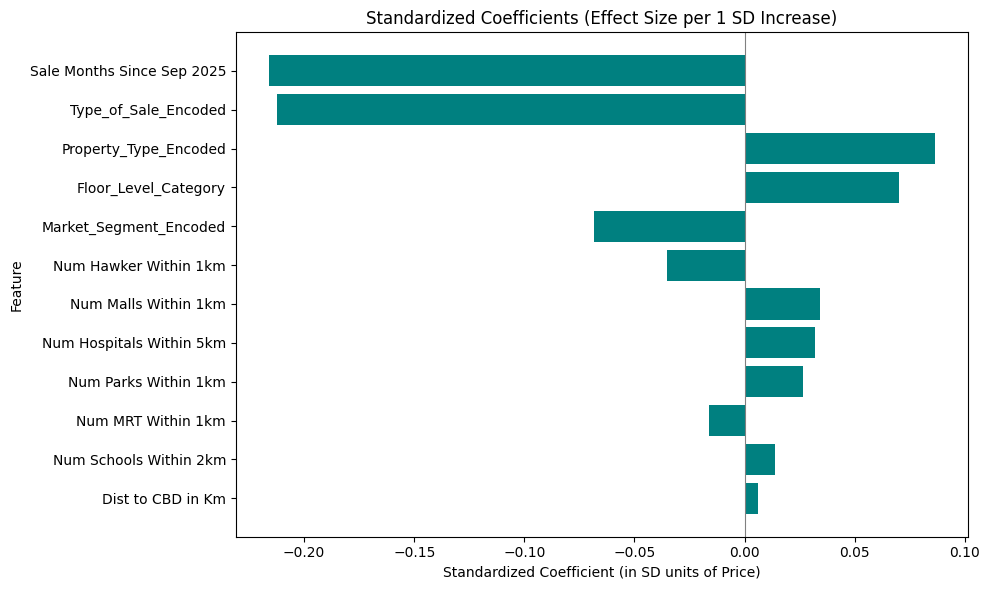


Model R²: 0.10512287685640909
Adjusted R²: 0.10502377548524722

Significant features (p < 0.05):
[0.00000000e+000 5.20879406e-007 1.85670907e-031 4.37444514e-026
 5.99256692e-019 9.04171570e-006 2.80543981e-019 3.25339178e-127
 0.00000000e+000 6.57209753e-174 1.60274914e-101]


In [17]:
# --- Imports ---
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# --- Config ---
target_col = 'Transacted Price ($)'

# Features to include (ensure these exist in df)
feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded'
]

# --- Step 1: Drop NaNs and prepare data ---
subset = df[feature_cols + [target_col]].dropna()
X = subset[feature_cols].astype(float)
y = subset[target_col].astype(float)

# --- Step 2: Standardize predictors and dependent variable ---
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).ravel()

# --- Step 3: Fit standardized OLS model ---
X_sm = sm.add_constant(X_scaled, has_constant='add')
model = sm.OLS(y_scaled, X_sm).fit()

# --- Step 4: Extract standardized coefficients and stats ---
coef_df = pd.DataFrame({
    'Feature': ['Intercept'] + feature_cols,
    'Standardized_Coefficient': model.params
})

# remove intercept row
coef_df = coef_df[coef_df['Feature'] != 'Intercept']

# absolute importance (for ranking)
coef_df['Abs_Coefficient'] = coef_df['Standardized_Coefficient'].abs()

# sort descending by absolute effect size
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False).reset_index(drop=True)

# --- Step 5: Interpretable version (in dollars per SD change) ---
# Convert standardized effect back to actual $ change per 1 SD increase in feature
# (multiply standardized coefficient * std of y)
std_y = np.std(y)
coef_df['$ Impact per 1 SD increase'] = coef_df['Standardized_Coefficient'] * std_y
coef_df['Interpretation'] = coef_df.apply(
    lambda row: f"1 SD increase in {row['Feature']} → ${row['$ Impact per 1 SD increase']:.0f} change in price",
    axis=1
)

# --- Step 6: Print Results ---
print("\n===== Standardized Coefficients (All Features) =====\n")
print(coef_df[['Feature', 'Standardized_Coefficient', '$ Impact per 1 SD increase', 'Interpretation']])

# --- Step 7: Optional — visualize effect sizes ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(coef_df['Feature'], coef_df['Standardized_Coefficient'], color='teal')
plt.axvline(0, color='gray', linewidth=0.8)
plt.title("Standardized Coefficients (Effect Size per 1 SD Increase)")
plt.xlabel("Standardized Coefficient (in SD units of Price)")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# --- Optional: Model performance summary ---
print("\nModel R²:", model.rsquared)
print("Adjusted R²:", model.rsquared_adj)
print("\nSignificant features (p < 0.05):")
print(model.pvalues[model.pvalues < 0.05])


## Threshold Analysis

In [18]:
import pandas as pd
import numpy as np

# --- Configuration ---
target_col = 'Transacted Price ($)'

# Amenity columns
amenities = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded'
]

# Define generic bin thresholds for all amenities (adjust as appropriate)
# Example interpretation:
# 0 = None, 1-3 = Low, 3-5 = Medium, >5 = High
bins = [0, 1, 3, 5, 10]
labels = ['None', 'Low', 'Medium', 'High']

# --- Function to perform threshold analysis for one feature ---
def threshold_analysis(df, feature, target, bins, labels):
    data = df[[feature, target]].dropna().copy()
    data['level'] = pd.cut(data[feature], bins=bins, labels=labels, include_lowest=True)
    
    # Mean and count of price by level
    agg = data.groupby('level')[target].agg(['mean', 'count']).reset_index()
    agg['marginal_effect'] = agg['mean'].diff()
    agg['marginal_effect'] = agg['marginal_effect'].fillna(0)
    
    print(f"\n=== {feature} Threshold Effects ===")
    for i in range(1, len(agg)):
        prev_label = agg.loc[i-1, 'level']
        curr_label = agg.loc[i, 'level']
        delta = agg.loc[i, 'marginal_effect']
        print(f"- {prev_label} → {curr_label}: +${delta:,.0f} average change in price")
    
    print("Insight:", end=" ")
    if agg['marginal_effect'].iloc[1:].abs().mean() > 0:
        diminishing = (agg['marginal_effect'].iloc[1:].diff().mean() < 0)
        if diminishing:
            print("Diminishing returns observed at higher amenity levels.")
        else:
            print("Returns remain steady or increase.")
    else:
        print("Minimal effect observed.")
    
    return agg

# --- Run for all amenities ---
results = {}
for feature in amenities:
    if feature in df.columns:
        results[feature] = threshold_analysis(df, feature, target_col, bins, labels)



=== Dist to CBD in Km Threshold Effects ===
- None → Low: +$0 average change in price
- Low → Medium: +$0 average change in price
- Medium → High: +$-0 average change in price
Insight: Diminishing returns observed at higher amenity levels.

=== Sale Months Since Sep 2025 Threshold Effects ===
- None → Low: +$-0 average change in price
- Low → Medium: +$0 average change in price
- Medium → High: +$0 average change in price
Insight: Returns remain steady or increase.

=== Num MRT Within 1km Threshold Effects ===
- None → Low: +$-0 average change in price
- Low → Medium: +$0 average change in price
- Medium → High: +$0 average change in price
Insight: Returns remain steady or increase.

=== Num Hawker Within 1km Threshold Effects ===
- None → Low: +$0 average change in price
- Low → Medium: +$0 average change in price
- Medium → High: +$0 average change in price
Insight: Returns remain steady or increase.

=== Num Malls Within 1km Threshold Effects ===
- None → Low: +$0 average change in

In [19]:
import pandas as pd
import numpy as np

# --- Configuration ---
target_col = 'Transacted Price ($)'

# Amenity columns
amenities = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded'
]

# Define bin thresholds and labels
bins = [0, 1, 3, 5, 10]
labels = ['None', 'Low', 'Medium', 'High']

# Minimum sample size per district to ensure stable averages
MIN_SAMPLES_PER_DISTRICT = 50

# --- Helper function: perform threshold analysis for one feature ---
def threshold_analysis(df, feature, target, bins, labels):
    """Returns aggregated mean price and marginal effects per level."""
    data = df[[feature, target]].dropna().copy()
    if data.empty:
        return None
    data['level'] = pd.cut(data[feature], bins=bins, labels=labels, include_lowest=True)
    agg = data.groupby('level')[target].agg(['mean', 'count']).reset_index()
    agg['marginal_effect'] = agg['mean'].diff().fillna(0)
    return agg

# --- Run analysis per district ---
districts = sorted(df['District'].dropna().unique())
results = []  # container for all district-level results

for dist in districts:
    df_dist = df[df['District'] == dist]
    n_dist = len(df_dist)
    if n_dist < MIN_SAMPLES_PER_DISTRICT:
        print(f"Skipping District {dist}: insufficient data ({n_dist} rows)")
        continue

    print(f"\n==============================")
    print(f"District {dist} — n={n_dist}")
    print("==============================")

    for feature in amenities:
        if feature not in df.columns:
            continue

        agg = threshold_analysis(df_dist, feature, target_col, bins, labels)
        if agg is None or agg['count'].sum() < 20:
            continue

        # Store results in the summary list
        for i in range(1, len(agg)):
            prev_label = agg.loc[i - 1, 'level']
            curr_label = agg.loc[i, 'level']
            delta = agg.loc[i, 'marginal_effect']

            results.append({
                'District': dist,
                'Feature': feature,
                'From_Level': prev_label,
                'To_Level': curr_label,
                'ΔPrice': delta,
                'AvgPrice_From': agg.loc[i - 1, 'mean'],
                'AvgPrice_To': agg.loc[i, 'mean'],
                'Count_From': agg.loc[i - 1, 'count'],
                'Count_To': agg.loc[i, 'count']
            })

        # --- Print quick insights ---
        print(f"\n{feature} Threshold Effects:")
        for i in range(1, len(agg)):
            prev_label = agg.loc[i-1, 'level']
            curr_label = agg.loc[i, 'level']
            delta = agg.loc[i, 'marginal_effect']
            print(f"- {prev_label} → {curr_label}: +${delta:,.0f} average change in price")

        diminishing = (agg['marginal_effect'].iloc[1:].diff().mean() < 0)
        if diminishing:
            print("Insight: Diminishing returns observed at higher levels.")
        else:
            print("Insight: Returns remain steady or increase.")

# --- Convert all results into a single DataFrame ---
threshold_df = pd.DataFrame(results)
if not threshold_df.empty:
    threshold_df = threshold_df.sort_values(['Feature', 'District', 'From_Level'])
    print("\n===== Summary of Threshold Effects (first 20 rows) =====")
    print(threshold_df.head(20))
    threshold_df.to_csv("district_threshold_analysis.csv", index=False)
    print("\nSaved full threshold analysis to 'district_threshold_analysis.csv'")
else:
    print("\nNo valid results — check if feature columns or data distributions are sufficient.")



District 1 — n=1638

Dist to CBD in Km Threshold Effects:
- None → Low: +$-0 average change in price
- Low → Medium: +$0 average change in price
- Medium → High: +$0 average change in price
Insight: Returns remain steady or increase.

Sale Months Since Sep 2025 Threshold Effects:
- None → Low: +$-0 average change in price
- Low → Medium: +$0 average change in price
- Medium → High: +$0 average change in price
Insight: Returns remain steady or increase.

Num MRT Within 1km Threshold Effects:
- None → Low: +$-0 average change in price
- Low → Medium: +$0 average change in price
- Medium → High: +$0 average change in price
Insight: Returns remain steady or increase.

Num Hawker Within 1km Threshold Effects:
- None → Low: +$-0 average change in price
- Low → Medium: +$0 average change in price
- Medium → High: +$0 average change in price
Insight: Returns remain steady or increase.

Num Malls Within 1km Threshold Effects:
- None → Low: +$-0 average change in price
- Low → Medium: +$0 avera

## Non-linear Modelling

## XGBoost

In [2]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



===== Full Sample Metrics =====
R2: 0.9706
RMSE: 0.1724
MAE: 0.1074
MAPE: 319745.1462

===== Cross-Validation Metrics (5-Fold) =====
CV_R2_mean: 0.8232
CV_R2_std: 0.0904
CV_RMSE_mean: 0.4171
CV_MAE_mean: 0.1200
CV_MAPE_mean: 319469.4328

===== Top Features by Importance =====
                   Feature  Importance
               Area (SQFT)    0.277806
    Market_Segment_Encoded    0.163153
      Type_of_Sale_Encoded    0.154333
Sale Months Since Sep 2025    0.065074
        Num MRT Within 1km    0.061154
      Num Malls Within 1km    0.057068
     Property_Type_Encoded    0.046138
     Num Hawker Within 1km    0.042055
  Num Hospitals Within 5km    0.038333
      Num Parks Within 1km    0.027361


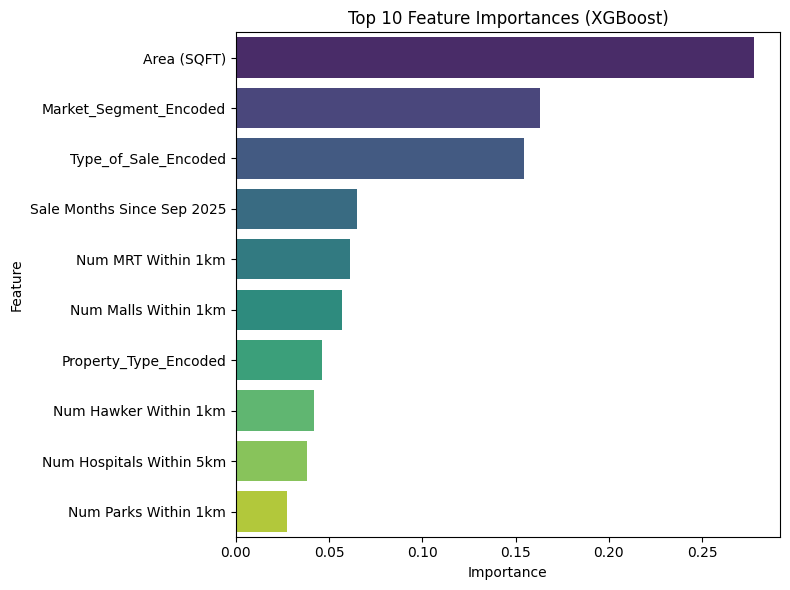


===== XGBoost Model Summary =====
R2: 0.9706
RMSE: 0.1724
MAE: 0.1074
MAPE: 319745.1462
CV_R2_mean: 0.8232
CV_R2_std: 0.0904
CV_RMSE_mean: 0.4171
CV_MAE_mean: 0.1200
CV_MAPE_mean: 319469.4328


In [14]:
# --- XGBoost Regression with CV and Scoring ---
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

# --- CONFIG ---
target_col = 'Transacted Price ($)'
feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded',
    'Area (SQFT)'
]
feature_cols = [f for f in feature_cols if f in df.columns]

CV_FOLDS = 5
RANDOM_STATE = 42
MIN_ROWS = 100
EPS = 1e-6  # to avoid divide by zero in MAPE

# --- Safe metrics ---
def safe_mape(y_true, y_pred):
    y_true = np.maximum(np.asarray(y_true, dtype=float), EPS)
    return mean_absolute_percentage_error(y_true, y_pred)

def compute_metrics(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred, squared=False),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': safe_mape(y_true, y_pred)
    }

# --- Prepare Data ---
data = df[feature_cols + [target_col]].dropna().copy()
if len(data) < MIN_ROWS:
    raise ValueError(f"Insufficient samples ({len(data)}) for modeling. Need ≥ {MIN_ROWS}.")

X = data[feature_cols].astype(float)
y = data[target_col].astype(float)

# --- XGBoost Configuration ---
xgb_params = dict(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# --- Full-Sample Fit ---
xgb_full = XGBRegressor(**xgb_params)
xgb_full.fit(X, y)

y_pred_full = xgb_full.predict(X)
full_metrics = compute_metrics(y, y_pred_full)

print("\n===== Full Sample Metrics =====")
for k, v in full_metrics.items():
    print(f"{k}: {v:.4f}")

# --- Cross-Validation Metrics ---
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_r2s, cv_rmses, cv_maes, cv_mapes = [], [], [], []

for train_idx, val_idx in kf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model_cv = XGBRegressor(**xgb_params)
    model_cv.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    y_val_pred = model_cv.predict(X_val)
    m = compute_metrics(y_val, y_val_pred)

    cv_r2s.append(m['R2'])
    cv_rmses.append(m['RMSE'])
    cv_maes.append(m['MAE'])
    cv_mapes.append(m['MAPE'])

# --- Aggregate CV Results ---
cv_results = {
    'CV_R2_mean': np.mean(cv_r2s),
    'CV_R2_std': np.std(cv_r2s),
    'CV_RMSE_mean': np.mean(cv_rmses),
    'CV_MAE_mean': np.mean(cv_maes),
    'CV_MAPE_mean': np.mean(cv_mapes)
}

print("\n===== Cross-Validation Metrics (5-Fold) =====")
for k, v in cv_results.items():
    print(f"{k}: {v:.4f}")

# --- Feature Importance ---
import matplotlib.pyplot as plt
import seaborn as sns

importance = xgb_full.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print("\n===== Top Features by Importance =====")
print(feat_imp_df.head(10).to_string(index=False))

# --- Plot Feature Importances ---
plt.figure(figsize=(8,6))
sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

# --- Summary Output ---
summary = {
    **full_metrics,
    **cv_results
}
print("\n===== XGBoost Model Summary =====")
for k, v in summary.items():
    print(f"{k}: {v:.4f}")


### XGBoost Excluding Area


===== Full Sample Metrics =====
R2: 0.5513
RMSE: 0.6734
MAE: 0.4586
MAPE: 213082.9974

===== Cross-Validation Metrics (5-Fold) =====
CV_R2_mean: 0.3909
CV_R2_std: 0.0580
CV_RMSE_mean: 0.7838
CV_MAE_mean: 0.4755
CV_MAPE_mean: 213257.7481

===== Top Features by Importance =====
                 Feature  Importance
    Type_of_Sale_Encoded    0.194723
  Market_Segment_Encoded    0.114167
      Num MRT Within 1km    0.106406
       Dist to CBD in Km    0.086274
   Property_Type_Encoded    0.085255
   Num Hawker Within 1km    0.077452
Num Hospitals Within 5km    0.071510
    Num Malls Within 1km    0.060560
    Num Parks Within 1km    0.057476
  Num Schools Within 2km    0.051758


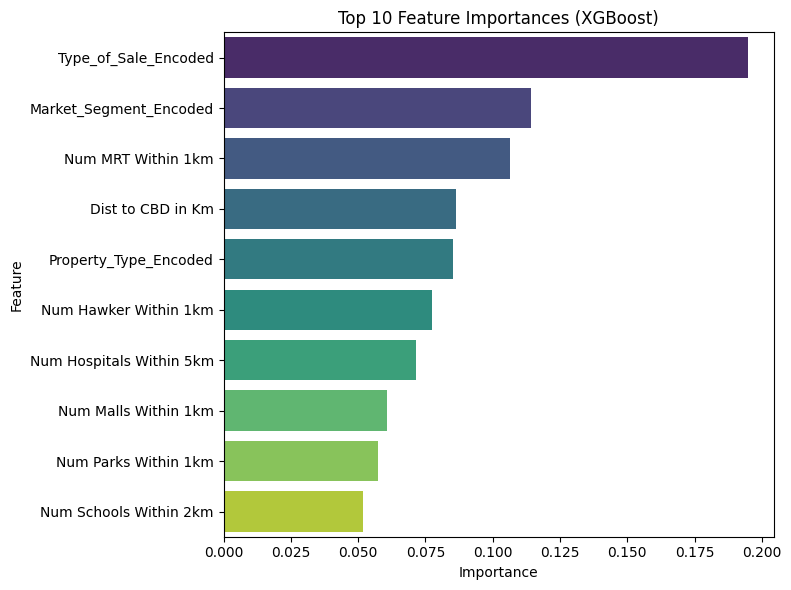


===== XGBoost Model Summary =====
R2: 0.5513
RMSE: 0.6734
MAE: 0.4586
MAPE: 213082.9974
CV_R2_mean: 0.3909
CV_R2_std: 0.0580
CV_RMSE_mean: 0.7838
CV_MAE_mean: 0.4755
CV_MAPE_mean: 213257.7481


In [12]:
# --- XGBoost Regression with CV and Scoring ---
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

# --- CONFIG ---
target_col = 'Transacted Price ($)'
feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded'
]
feature_cols = [f for f in feature_cols if f in df.columns]

CV_FOLDS = 5
RANDOM_STATE = 42
MIN_ROWS = 100
EPS = 1e-6  # to avoid divide by zero in MAPE

# --- Safe metrics ---
def safe_mape(y_true, y_pred):
    y_true = np.maximum(np.asarray(y_true, dtype=float), EPS)
    return mean_absolute_percentage_error(y_true, y_pred)

def compute_metrics(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred, squared=False),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': safe_mape(y_true, y_pred)
    }

# --- Prepare Data ---
data = df[feature_cols + [target_col]].dropna().copy()
if len(data) < MIN_ROWS:
    raise ValueError(f"Insufficient samples ({len(data)}) for modeling. Need ≥ {MIN_ROWS}.")

X = data[feature_cols].astype(float)
y = data[target_col].astype(float)

# --- XGBoost Configuration ---
xgb_params = dict(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# --- Full-Sample Fit ---
xgb_full = XGBRegressor(**xgb_params)
xgb_full.fit(X, y)

y_pred_full = xgb_full.predict(X)
full_metrics = compute_metrics(y, y_pred_full)

print("\n===== Full Sample Metrics =====")
for k, v in full_metrics.items():
    print(f"{k}: {v:.4f}")

# --- Cross-Validation Metrics ---
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_r2s, cv_rmses, cv_maes, cv_mapes = [], [], [], []

for train_idx, val_idx in kf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model_cv = XGBRegressor(**xgb_params)
    model_cv.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    y_val_pred = model_cv.predict(X_val)
    m = compute_metrics(y_val, y_val_pred)

    cv_r2s.append(m['R2'])
    cv_rmses.append(m['RMSE'])
    cv_maes.append(m['MAE'])
    cv_mapes.append(m['MAPE'])

# --- Aggregate CV Results ---
cv_results = {
    'CV_R2_mean': np.mean(cv_r2s),
    'CV_R2_std': np.std(cv_r2s),
    'CV_RMSE_mean': np.mean(cv_rmses),
    'CV_MAE_mean': np.mean(cv_maes),
    'CV_MAPE_mean': np.mean(cv_mapes)
}

print("\n===== Cross-Validation Metrics (5-Fold) =====")
for k, v in cv_results.items():
    print(f"{k}: {v:.4f}")

# --- Feature Importance ---
import matplotlib.pyplot as plt
import seaborn as sns

importance = xgb_full.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print("\n===== Top Features by Importance =====")
print(feat_imp_df.head(10).to_string(index=False))

# --- Plot Feature Importances ---
plt.figure(figsize=(8,6))
sns.barplot(data=feat_imp_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

# --- Summary Output ---
summary = {
    **full_metrics,
    **cv_results
}
print("\n===== XGBoost Model Summary =====")
for k, v in summary.items():
    print(f"{k}: {v:.4f}")


Running XGBoost model for 27 districts...


District 1 (n=1638) — training model...
  → R² = 0.747, CV R² = 0.104
  Top 3 features: ['Property_Type_Encoded', 'Num Hawker Within 1km', 'Dist to CBD in Km']

District 2 (n=1207) — training model...
  → R² = 0.970, CV R² = 0.412
  Top 3 features: ['Num MRT Within 1km', 'Floor_Level_Category', 'Sale Months Since Sep 2025']

District 3 (n=4625) — training model...
  → R² = 0.660, CV R² = 0.448
  Top 3 features: ['Num Hawker Within 1km', 'Num Hospitals Within 5km', 'Dist to CBD in Km']

District 4 (n=2112) — training model...
  → R² = 0.798, CV R² = 0.436
  Top 3 features: ['Num Hawker Within 1km', 'Num Parks Within 1km', 'Num Hospitals Within 5km']

District 5 (n=7943) — training model...
  → R² = 0.599, CV R² = 0.448
  Top 3 features: ['Num MRT Within 1km', 'Type_of_Sale_Encoded', 'Property_Type_Encoded']

District 6 (n=705) — training model...
  → R² = 0.506, CV R² = 0.069
  Top 3 features: ['Num MRT Within 1km', 'Num Hawker Within 1km', 'N

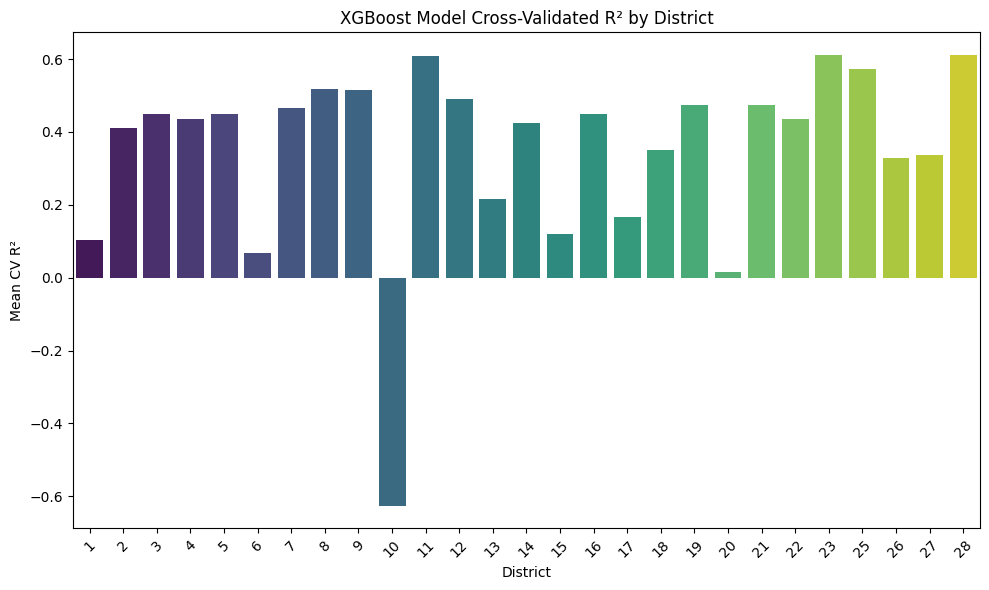

In [ ]:
# --- XGBoost Regression per District ---
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# --- CONFIG ---
target_col = 'Transacted Price ($)'
district_col = 'District'

# Features to use
feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Schools Within 2km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded'
]
feature_cols = [f for f in feature_cols if f in df.columns]

MIN_ROWS_PER_DISTRICT = 100
CV_FOLDS = 5
RANDOM_STATE = 42
EPS = 1e-6

# --- XGBoost Parameters ---
xgb_params = dict(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# --- Helpers ---
def safe_mape(y_true, y_pred):
    y_true = np.maximum(np.asarray(y_true, dtype=float), EPS)
    return mean_absolute_percentage_error(y_true, y_pred)

def compute_metrics(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred, squared=False),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': safe_mape(y_true, y_pred)
    }

# --- Containers ---
district_metrics = []  # for RMSE, R2, etc.
district_importances = []  # for feature importance

districts = sorted(df[district_col].dropna().unique())

print(f"Running XGBoost model for {len(districts)} districts...\n")

# --- Loop over districts ---
for dist in districts:
    df_dist = df[df[district_col] == dist].dropna(subset=[target_col] + feature_cols).copy()
    n = len(df_dist)
    if n < MIN_ROWS_PER_DISTRICT:
        print(f"Skipping District {dist} — only {n} samples (< {MIN_ROWS_PER_DISTRICT})")
        continue

    print(f"\nDistrict {dist} (n={n}) — training model...")

    X = df_dist[feature_cols].astype(float)
    y = df_dist[target_col].astype(float)

    # --- Full Sample Fit ---
    model_full = XGBRegressor(**xgb_params)
    model_full.fit(X, y)
    y_pred_full = model_full.predict(X)
    full_metrics = compute_metrics(y, y_pred_full)

    # --- Cross-Validation ---
    kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    cv_r2s, cv_rmses, cv_maes, cv_mapes = [], [], [], []

    for tr_idx, val_idx in kf.split(X, y):
        X_train, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model_cv = XGBRegressor(**xgb_params)
        model_cv.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        y_val_pred = model_cv.predict(X_val)
        m = compute_metrics(y_val, y_val_pred)

        cv_r2s.append(m['R2'])
        cv_rmses.append(m['RMSE'])
        cv_maes.append(m['MAE'])
        cv_mapes.append(m['MAPE'])

    cv_results = {
        'District': dist,
        'n': n,
        'R2_full': full_metrics['R2'],
        'RMSE_full': full_metrics['RMSE'],
        'MAE_full': full_metrics['MAE'],
        'MAPE_full': full_metrics['MAPE'],
        'CV_R2_mean': np.mean(cv_r2s),
        'CV_R2_std': np.std(cv_r2s),
        'CV_RMSE_mean': np.mean(cv_rmses),
        'CV_MAE_mean': np.mean(cv_maes),
        'CV_MAPE_mean': np.mean(cv_mapes)
    }
    district_metrics.append(cv_results)

    # --- Feature Importance ---
    imp = model_full.feature_importances_
    imp_df = pd.DataFrame({
        'District': dist,
        'Feature': feature_cols,
        'Importance': imp
    }).sort_values('Importance', ascending=False)
    district_importances.append(imp_df)

    print(f"  → R² = {full_metrics['R2']:.3f}, CV R² = {cv_results['CV_R2_mean']:.3f}")
    print(f"  Top 3 features: {imp_df.head(3)['Feature'].tolist()}")

# --- Combine all results ---
metrics_df = pd.DataFrame(district_metrics)
importances_df = pd.concat(district_importances, ignore_index=True)

# --- Save outputs ---
metrics_df.to_csv("xgb_district_metrics.csv", index=False)
importances_df.to_csv("xgb_district_feature_importances.csv", index=False)
print("\nSaved 'xgb_district_metrics.csv' and 'xgb_district_feature_importances.csv'.")

# --- Summary of Top Features per District ---
top_features = (
    importances_df.sort_values(['District','Importance'], ascending=[True, False])
    .groupby('District')
    .first()
    .reset_index()[['District','Feature','Importance']]
)
top_features = top_features.merge(
    metrics_df[['District','CV_R2_mean','CV_RMSE_mean','n']],
    on='District', how='left'
).sort_values('CV_R2_mean', ascending=False)

print("\n===== Top Feature per District (Ranked by CV R²) =====")
print(top_features.head(10).to_string(index=False))

# --- Optional Visualization ---
plt.figure(figsize=(10,6))
sns.barplot(data=metrics_df.sort_values('CV_R2_mean', ascending=False),
            x='District', y='CV_R2_mean', palette='viridis')
plt.title("XGBoost Model Cross-Validated R² by District")
plt.ylabel("Mean CV R²")
plt.xlabel("District")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


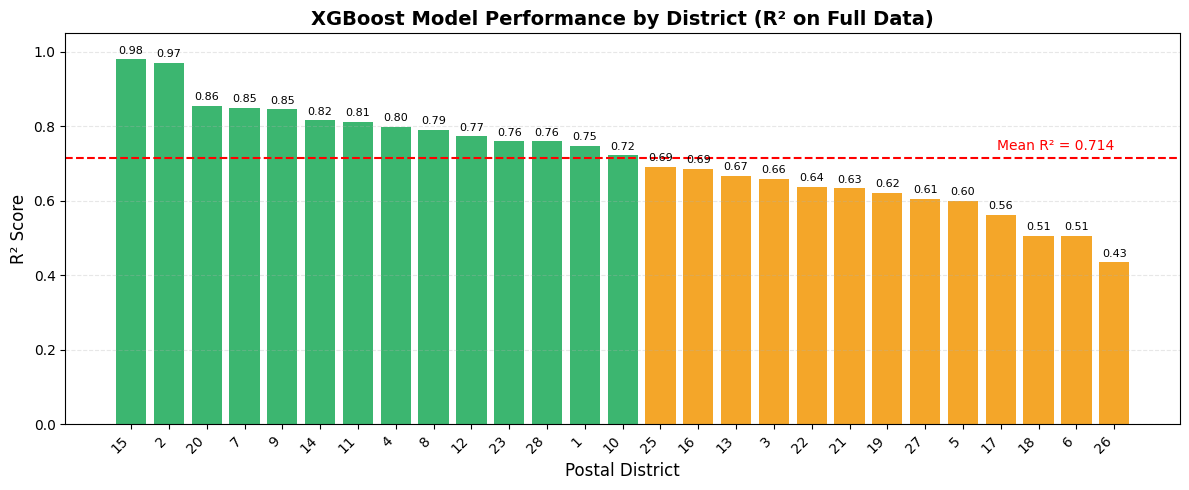

In [11]:
# --- Visualization: District Ranking by Actual R² (Full Sample) ---

# Sort districts by R² descending
metrics_sorted = metrics_df.sort_values("R2_full", ascending=False).reset_index(drop=True)

# Calculate mean R²
mean_r2 = metrics_sorted["R2_full"].mean()

# Define colors: green if above mean, orange if below
colors = [
    "#27ae60" if r2 >= mean_r2 else "#f39c12"
    for r2 in metrics_sorted["R2_full"]
]

# Plot
plt.figure(figsize=(12, 5))
bars = plt.bar(
    metrics_sorted["District"].astype(str),
    metrics_sorted["R2_full"],
    color=colors,
    alpha=0.9
)

# Add mean R² reference line
plt.axhline(mean_r2, color="red", linestyle="--", linewidth=1.5)
plt.text(
    len(metrics_sorted) - 1, mean_r2 + 0.015,
    f"Mean R² = {mean_r2:.3f}",
    color="red", fontsize=10, ha="right", va="bottom"
)

# Add text labels on top of bars (optional)
for i, (dist, r2) in enumerate(zip(metrics_sorted["District"], metrics_sorted["R2_full"])):
    plt.text(i, r2 + 0.01, f"{r2:.2f}", ha="center", va="bottom", fontsize=8, color="black")

# Customize chart
plt.title("XGBoost Model Performance by District (R² on Full Data)", fontsize=14, fontweight="bold")
plt.xlabel("Postal District", fontsize=12)
plt.ylabel("R² Score", fontsize=12)
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("xgb_r2_full_performance_by_district.png", dpi=300)
plt.show()


In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import XGBoost
try:
    import xgboost as xgb
    xgb_available = True
    print("✅ XGBoost imported successfully!")
except ImportError:
    xgb_available = False
    print("❌ XGBoost not available. Install with: pip install xgboost")

# Other non-linear models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.kernel_ridge import KernelRidge

print("🚀 DISTRICT 1 NON-LINEAR MODELING + XGBOOST (NO DOUBLE NORMALIZATION)")
print("="*75)

# Load District 1 data
district1_file = '../../datasets/normalized_data/district20_normalized.csv'
df_d1 = pd.read_csv(district1_file)

print(f"📊 District 1 Data: {len(df_d1):,} properties, {df_d1.shape[1]} features")

# Prepare features and target
feature_cols = [col for col in df_d1.columns if col != 'Transacted Price ($)']
X = df_d1[feature_cols]
y = df_d1['Transacted Price ($)']

print(f"🔍 Data characteristics:")
print(f"   • Features: {X.shape[1]}")
print(f"   • Target mean: {y.mean():.3f} (should be ~0 if normalized)")
print(f"   • Target std: {y.std():.3f} (should be ~1 if normalized)")
print(f"   ✅ Data is already normalized - NO additional scaling needed!")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\n📋 Data split: {len(X_train)} train, {len(X_test)} test")

ModuleNotFoundError: No module named 'matplotlib.backends.registry'

In [91]:
# Define comprehensive set of non-linear models INCLUDING XGBoost
print(f"\n🤖 CONFIGURING NON-LINEAR MODELS + XGBOOST")
print("-" * 75)

models = {}

# XGBoost variants (if available)
if xgb_available:
    models.update({
        'XGBoost (Default)': xgb.XGBRegressor(
            random_state=42, n_jobs=-1
        ),
        'XGBoost (Conservative)': xgb.XGBRegressor(
            n_estimators=100, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, 
            random_state=42, n_jobs=-1
        ),
        'XGBoost (Aggressive)': xgb.XGBRegressor(
            n_estimators=200, max_depth=8, learning_rate=0.15,
            subsample=0.9, colsample_bytree=0.9,
            random_state=42, n_jobs=-1
        ),
        'XGBoost (Balanced)': xgb.XGBRegressor(
            n_estimators=150, max_depth=6, learning_rate=0.1,
            subsample=0.85, colsample_bytree=0.85,
            reg_alpha=0.1, reg_lambda=0.1,
            random_state=42, n_jobs=-1
        ),
        'XGBoost (Deep)': xgb.XGBRegressor(
            n_estimators=300, max_depth=10, learning_rate=0.08,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.05, reg_lambda=0.05,
            random_state=42, n_jobs=-1
        ),
        'XGBoost (Regularized)': xgb.XGBRegressor(
            n_estimators=200, max_depth=5, learning_rate=0.1,
            subsample=0.7, colsample_bytree=0.7,
            reg_alpha=1.0, reg_lambda=1.0,
            random_state=42, n_jobs=-1
        ),
    })

# Tree-based ensembles
models.update({
    'Random Forest (Default)': RandomForestRegressor(random_state=42),
    'Random Forest (Deep)': RandomForestRegressor(
        n_estimators=200, max_depth=15, min_samples_split=2, 
        min_samples_leaf=1, random_state=42
    ),
    'Random Forest (Wide)': RandomForestRegressor(
        n_estimators=500, max_depth=8, min_samples_split=5,
        min_samples_leaf=2, random_state=42
    ),
    
    'Extra Trees (Default)': ExtraTreesRegressor(random_state=42),
    'Extra Trees (Aggressive)': ExtraTreesRegressor(
        n_estimators=300, max_depth=20, min_samples_split=2,
        min_samples_leaf=1, random_state=42
    ),
    
    # Gradient boosting 
    'Gradient Boosting (Default)': GradientBoostingRegressor(random_state=42),
    'Gradient Boosting (Conservative)': GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42
    ),
    'Gradient Boosting (Aggressive)': GradientBoostingRegressor(
        n_estimators=150, learning_rate=0.15, max_depth=8, random_state=42
    ),
})

# Support Vector Regression (working with normalized data)
models.update({
    'SVR (RBF Scale)': SVR(kernel='rbf', C=1.0, gamma='scale'),
    'SVR (RBF Auto)': SVR(kernel='rbf', C=1.0, gamma='auto'),
    'SVR (RBF Tuned)': SVR(kernel='rbf', C=10.0, gamma='scale', epsilon=0.1),
    'SVR (Polynomial)': SVR(kernel='poly', degree=2, C=1.0, gamma='scale'),
})

# K-Nearest Neighbors
models.update({
    'KNN (k=3)': KNeighborsRegressor(n_neighbors=3),
    'KNN (k=5)': KNeighborsRegressor(n_neighbors=5),
    'KNN (k=7)': KNeighborsRegressor(n_neighbors=7),
    'KNN (Distance Weighted)': KNeighborsRegressor(n_neighbors=5, weights='distance'),
})

# Neural Networks
models.update({
    'Neural Network (Small)': MLPRegressor(
        hidden_layer_sizes=(50,), activation='relu', solver='adam',
        alpha=0.01, max_iter=1000, random_state=42
    ),
    'Neural Network (Medium)': MLPRegressor(
        hidden_layer_sizes=(100, 50), activation='relu', solver='adam',
        alpha=0.01, max_iter=1000, random_state=42
    ),
    'Neural Network (Deep)': MLPRegressor(
        hidden_layer_sizes=(100, 50, 25), activation='relu', solver='adam',
        alpha=0.001, max_iter=2000, random_state=42
    ),
})

# Kernel Ridge (should work well with normalized data)
models.update({
    'Kernel Ridge (RBF Scale)': KernelRidge(kernel='rbf', alpha=1.0, gamma='scale'),
    'Kernel Ridge (RBF Auto)': KernelRidge(kernel='rbf', alpha=0.1, gamma='auto'),
    'Kernel Ridge (RBF Tuned)': KernelRidge(kernel='rbf', alpha=1.0, gamma=1.0),
    'Kernel Ridge (Polynomial)': KernelRidge(kernel='polynomial', degree=2, alpha=1.0),
})

# Decision Trees
models.update({
    'Decision Tree (Deep)': DecisionTreeRegressor(max_depth=15, random_state=42),
    'Decision Tree (Balanced)': DecisionTreeRegressor(
        max_depth=8, min_samples_split=5, min_samples_leaf=3, random_state=42
    ),
})

print(f"🎯 Testing {len(models)} different non-linear models:")
if xgb_available:
    print(f"   • XGBoost variants: {len([k for k in models.keys() if 'XGBoost' in k])}")
print(f"   • Tree-based: {len([k for k in models.keys() if any(t in k for t in ['Random Forest', 'Extra Trees', 'Gradient Boosting', 'Decision Tree'])])}")
print(f"   • SVR variants: {len([k for k in models.keys() if 'SVR' in k])}")
print(f"   • KNN variants: {len([k for k in models.keys() if 'KNN' in k])}")
print(f"   • Neural Networks: {len([k for k in models.keys() if 'Neural Network' in k])}")
print(f"   • Kernel Ridge: {len([k for k in models.keys() if 'Kernel Ridge' in k])}")


🤖 CONFIGURING NON-LINEAR MODELS + XGBOOST
---------------------------------------------------------------------------
🎯 Testing 31 different non-linear models:
   • XGBoost variants: 6
   • Tree-based: 10
   • SVR variants: 4
   • KNN variants: 4
   • Neural Networks: 3
   • Kernel Ridge: 4


In [92]:
# Train and evaluate all models (including XGBoost)
print(f"\n🔄 TRAINING AND EVALUATING ALL MODELS (INCLUDING XGBOOST)")
print("="*75)

results = []
model_predictions = {}

for i, (name, model) in enumerate(models.items(), 1):
    print(f"\n📊 {i:2d}/{len(models)}: {name}")
    
    try:
        # Train model on original normalized data (NO additional scaling!)
        model.fit(X_train, y_train)
        
        # Make predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        # Calculate metrics
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        
        # Cross-validation score (also on original data)
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()
        
        # Store results
        result = {
            'Model': name,
            'Train_R2': train_r2,
            'Test_R2': test_r2,
            'Train_RMSE': train_rmse,
            'Test_RMSE': test_rmse,
            'CV_R2_Mean': cv_mean,
            'CV_R2_Std': cv_std,
            'Overfitting': train_r2 - test_r2,
        }
        results.append(result)
        model_predictions[name] = y_test_pred
        
        # Performance indicator
        if test_r2 > 0.5:
            indicator = "🌟 EXCELLENT"
        elif test_r2 > 0.3:
            indicator = "✅ GOOD"
        elif test_r2 > 0.15:
            indicator = "📊 MODERATE"
        elif test_r2 > 0.05:
            indicator = "⚠️ WEAK"
        else:
            indicator = "🚨 POOR"
            
        print(f"      Test R²: {test_r2:.3f} | CV: {cv_mean:.3f}±{cv_std:.3f} | {indicator}")
        
        # Special celebration for XGBoost if it performs well
        if 'XGBoost' in name and test_r2 > 0.3:
            print(f"      🚀 XGBoost showing strong performance!")
            
    except Exception as e:
        print(f"      ❌ Failed: {str(e)[:60]}")
        continue

print(f"\n✅ Completed training {len(results)} models successfully!")


🔄 TRAINING AND EVALUATING ALL MODELS (INCLUDING XGBOOST)

📊  1/31: XGBoost (Default)
      Test R²: 0.132 | CV: 0.167±0.091 | ⚠️ WEAK

📊  2/31: XGBoost (Conservative)
      Test R²: 0.306 | CV: 0.295±0.022 | ✅ GOOD
      🚀 XGBoost showing strong performance!

📊  3/31: XGBoost (Aggressive)
      Test R²: 0.107 | CV: 0.115±0.093 | ⚠️ WEAK

📊  4/31: XGBoost (Balanced)
      Test R²: 0.209 | CV: 0.230±0.066 | 📊 MODERATE

📊  5/31: XGBoost (Deep)
      Test R²: 0.058 | CV: 0.090±0.099 | ⚠️ WEAK

📊  6/31: XGBoost (Regularized)
      Test R²: 0.277 | CV: 0.268±0.046 | 📊 MODERATE

📊  7/31: Random Forest (Default)
      Test R²: 0.210 | CV: 0.217±0.044 | 📊 MODERATE

📊  8/31: Random Forest (Deep)
      Test R²: 0.224 | CV: 0.239±0.040 | 📊 MODERATE

📊  9/31: Random Forest (Wide)
      Test R²: 0.294 | CV: 0.296±0.013 | 📊 MODERATE

📊 10/31: Extra Trees (Default)
      Test R²: 0.084 | CV: 0.072±0.060 | ⚠️ WEAK

📊 11/31: Extra Trees (Aggressive)
      Test R²: 0.091 | CV: 0.078±0.056 | ⚠️ WEAK

📊 1

In [93]:
# Comprehensive analysis including XGBoost
print(f"\n🏆 COMPLETE MODEL PERFORMANCE RANKING (INCLUDING XGBOOST)")
print("="*85)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test_R2', ascending=False)

print(f"{'Rank':<4} {'Model':<35} {'Test R²':<8} {'CV R²':<12} {'Overfit':<8} {'Status'}")
print("-" * 85)

for i, (_, row) in enumerate(results_df.iterrows(), 1):
    # Overfitting assessment
    if row['Overfitting'] > 0.15:
        overfit_flag = "🚨 High"
    elif row['Overfitting'] > 0.08:
        overfit_flag = "⚠️ Med"
    else:
        overfit_flag = "✅ Low"
    
    # Performance status
    if row['Test_R2'] > 0.4:
        status = "🏆"
    elif row['Test_R2'] > 0.3:
        status = "🌟"
    elif row['Test_R2'] > 0.2:
        status = "✅"
    elif row['Test_R2'] > 0.1:
        status = "📊"
    else:
        status = "⚠️"
    
    # Highlight XGBoost models
    model_name = row['Model']
    if 'XGBoost' in model_name:
        model_name = f"🚀 {model_name}"
    
    print(f"{i:<4} {model_name:<35} {row['Test_R2']:<8.3f} "
          f"{row['CV_R2_Mean']:<6.3f}±{row['CV_R2_Std']:<4.3f} "
          f"{overfit_flag:<8} {status}")

# Analyze XGBoost performance specifically
if xgb_available and len([r for r in results if 'XGBoost' in r['Model']]) > 0:
    print(f"\n🚀 XGBOOST PERFORMANCE ANALYSIS")
    print("-" * 60)
    
    xgb_results = [r for r in results if 'XGBoost' in r['Model']]
    xgb_df = pd.DataFrame(xgb_results).sort_values('Test_R2', ascending=False)
    
    print(f"🏆 Best XGBoost: {xgb_df.iloc[0]['Model']}")
    print(f"   📊 Test R²: {xgb_df.iloc[0]['Test_R2']:.4f}")
    print(f"   🔄 CV Score: {xgb_df.iloc[0]['CV_R2_Mean']:.4f} ± {xgb_df.iloc[0]['CV_R2_Std']:.4f}")
    
    print(f"\n📈 XGBoost vs Other Algorithms:")
    best_xgb_r2 = xgb_df.iloc[0]['Test_R2']
    best_overall_r2 = results_df.iloc[0]['Test_R2']
    
    if best_xgb_r2 == best_overall_r2:
        print(f"   🏆 XGBoost WINS! Best overall performance!")
    elif best_xgb_r2 >= best_overall_r2 * 0.95:
        print(f"   🥈 XGBoost very competitive! Within 5% of best model")
    elif best_xgb_r2 >= best_overall_r2 * 0.90:
        print(f"   🥉 XGBoost solid performance! Within 10% of best model")
    else:
        print(f"   📊 XGBoost decent but other algorithms perform better")

# Overall champion analysis
best_model = results_df.iloc[0]
print(f"\n🎯 ULTIMATE CHAMPION: {best_model['Model']}")
print(f"   📊 Test R²: {best_model['Test_R2']:.4f} ({best_model['Test_R2']*100:.1f}% variance explained)")
print(f"   🔄 Cross-validation: {best_model['CV_R2_Mean']:.4f} ± {best_model['CV_R2_Std']:.4f}")
print(f"   🎯 Overfitting: {best_model['Overfitting']:.4f}")
print(f"   📏 Test RMSE: {best_model['Test_RMSE']:.4f}")

# Compare with linear baseline
linear_baseline = 0.1085  # From previous stepwise regression
improvement = best_model['Test_R2'] - linear_baseline
improvement_pct = (improvement / linear_baseline) * 100

print(f"\n📈 IMPROVEMENT OVER LINEAR BASELINE:")
print(f"   • Linear model R²: {linear_baseline:.4f}")
print(f"   • Best non-linear R²: {best_model['Test_R2']:.4f}")
print(f"   • Absolute improvement: +{improvement:.4f}")
print(f"   • Relative improvement: {improvement_pct:+.1f}%")

if improvement > 0.2:
    verdict = "🌟 MASSIVE BREAKTHROUGH! Non-linear modeling dominates!"
elif improvement > 0.15:
    verdict = "🚀 EXCELLENT IMPROVEMENT! Non-linear relationships captured!"
elif improvement > 0.1:
    verdict = "✅ SUBSTANTIAL IMPROVEMENT! Clear non-linear benefits!"
elif improvement > 0.05:
    verdict = "📊 GOOD IMPROVEMENT! Some non-linearity detected!"
else:
    verdict = "⚠️ LIMITED IMPROVEMENT! Linear model was quite competitive!"

print(f"\n💡 FINAL VERDICT: {verdict}")

# Show top 5 models for quick reference
print(f"\n🏅 TOP 5 MODELS:")
print("-" * 50)
for i, (_, row) in enumerate(results_df.head(5).iterrows(), 1):
    print(f"   {i}. {row['Model']:<30} R² = {row['Test_R2']:.4f}")


🏆 COMPLETE MODEL PERFORMANCE RANKING (INCLUDING XGBOOST)
Rank Model                               Test R²  CV R²        Overfit  Status
-------------------------------------------------------------------------------------
1    🚀 XGBoost (Conservative)            0.306    0.295 ±0.022 ⚠️ Med   🌟
2    Random Forest (Wide)                0.294    0.296 ±0.013 🚨 High   ✅
3    🚀 XGBoost (Regularized)             0.277    0.268 ±0.046 🚨 High   ✅
4    Random Forest (Deep)                0.224    0.239 ±0.040 🚨 High   ✅
5    Decision Tree (Balanced)            0.213    0.190 ±0.029 🚨 High   ✅
6    Random Forest (Default)             0.210    0.217 ±0.044 🚨 High   ✅
7    🚀 XGBoost (Balanced)                0.209    0.230 ±0.066 🚨 High   ✅
8    🚀 XGBoost (Default)                 0.132    0.167 ±0.091 🚨 High   📊
9    🚀 XGBoost (Aggressive)              0.107    0.115 ±0.093 🚨 High   📊
10   Extra Trees (Aggressive)            0.091    0.078 ±0.056 🚨 High   ⚠️
11   Extra Trees (Default)          

In [9]:
import pandas as pd
import numpy as np
import warnings
import glob
import os
import time
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
from sklearn.model_selection import cross_val_score
warnings.filterwarnings('ignore')

class XGBoostSingaporeOptimizer:
    """
    PURE XGBOOST Singapore Property Price Predictor
    Advanced Hyperparameter Optimization for 112k+ Properties
    """
    
    def __init__(self, data_folder):
        self.data_folder = data_folder
        self.df = None
        self.X = None
        self.y = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.district_info = {}
        self.optimization_results = {}
        self.best_model = None
        self.best_score = 0
        self.best_params = {}
        
    def load_singapore_dataset(self):
        """Load and combine all Singapore districts"""
        print(f"🚀 XGBOOST SINGAPORE PROPERTY OPTIMIZER")
        print("="*80)
        
        district_files = glob.glob(os.path.join(self.data_folder, "*normalized.csv"))
        district_files.sort()
        
        if not district_files:
            raise Exception(f"No files found in {self.data_folder}")
        
        print(f"\n🏠 Loading {len(district_files)} Singapore districts:")
        
        all_dataframes = []
        
        for file_path in district_files:
            try:
                filename = os.path.basename(file_path)
                district_num = int(''.join(filter(str.isdigit, filename)))
                
                df_district = pd.read_csv(file_path)
                df_district['District_Number'] = district_num
                
                all_dataframes.append(df_district)
                
                self.district_info[f"District_{district_num}"] = {
                    'samples': len(df_district),
                    'district_number': district_num
                }
                
                print(f"   ✅ District {district_num:>2}: {len(df_district):>6} properties")
                
            except Exception as e:
                print(f"   ❌ Failed to load {filename}: {e}")
                continue
        
        # Combine all districts
        self.df = pd.concat(all_dataframes, ignore_index=True)
        
        print(f"\n🎯 SINGAPORE DATASET LOADED:")
        print(f"   • Total Districts: {len(self.district_info)}")
        print(f"   • Total Properties: {len(self.df):,}")
        print(f"   • Features: {self.df.shape[1] - 1}")
        
        return True
    
    def engineer_features(self):
        """Create XGBoost-optimized features"""
        print(f"\n⚙️ FEATURE ENGINEERING FOR XGBOOST:")
        print("-" * 50)
        
        target_col = 'Transacted Price ($)'
        
        # Separate target
        self.y = self.df[target_col].values
        feature_df = self.df.drop(target_col, axis=1)
        
        # Create district dummy variables (XGBoost handles categoricals well)
        district_dummies = pd.get_dummies(feature_df['District_Number'], prefix='District')
        
        # Combine features
        self.X = pd.concat([
            feature_df.drop('District_Number', axis=1),
            district_dummies
        ], axis=1)
        
        print(f"✅ XGBoost Features Ready:")
        print(f"   • Original features: {feature_df.shape[1] - 1}")
        print(f"   • District features: {len(district_dummies.columns)}")
        print(f"   • Total features: {self.X.shape[1]}")
        print(f"   • Target range: [{self.y.min():.0f}, {self.y.max():.0f}]")
        
        return True
    
    def split_dataset(self):
        """Split dataset for XGBoost training"""
        print(f"\n📊 SPLITTING DATASET:")
        print("-" * 30)
        
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, 
            test_size=0.2, 
            random_state=42,
            shuffle=True
        )
        
        print(f"✅ Dataset Split:")
        print(f"   • Training: {len(self.X_train):,} properties")
        print(f"   • Testing: {len(self.X_test):,} properties")
        print(f"   • Features: {self.X_train.shape[1]}")
        
        return True
    
    def baseline_xgboost(self):
        """Train baseline XGBoost model"""
        print(f"\n🎯 BASELINE XGBOOST MODEL:")
        print("-" * 40)
        
        # Default XGBoost parameters
        baseline_model = xgb.XGBRegressor(
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1
        )
        
        print("🚀 Training baseline model...")
        start_time = time.time()
        
        baseline_model.fit(self.X_train, self.y_train)
        training_time = time.time() - start_time
        
        # Evaluate baseline
        y_pred_train = baseline_model.predict(self.X_train)
        y_pred_test = baseline_model.predict(self.X_test)
        
        train_r2 = r2_score(self.y_train, y_pred_train)
        test_r2 = r2_score(self.y_test, y_pred_test)
        test_rmse = np.sqrt(mean_squared_error(self.y_test, y_pred_test))
        test_mae = mean_absolute_error(self.y_test, y_pred_test)
        
        # Cross-validation
        cv_scores = cross_val_score(baseline_model, self.X_train, self.y_train, 
                                  cv=5, scoring='r2', n_jobs=-1)
        
        self.optimization_results['Baseline_XGBoost'] = {
            'model': baseline_model,
            'params': baseline_model.get_params(),
            'train_r2': train_r2,
            'test_r2': test_r2,
            'test_rmse': test_rmse,
            'test_mae': test_mae,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'training_time': training_time
        }
        
        self.best_model = baseline_model
        self.best_score = test_r2
        self.best_params = baseline_model.get_params()
        
        print(f"✅ Baseline Results:")
        print(f"   • Train R²: {train_r2:.4f}")
        print(f"   • Test R²: {test_r2:.4f}")
        print(f"   • CV Score: {cv_scores.mean():.4f} ± {cv_scores.std():.3f}")
        print(f"   • RMSE: {test_rmse:.0f}")
        print(f"   • MAE: {test_mae:.0f}")
        print(f"   • Training Time: {training_time:.1f}s")
        
        return True
    
    def grid_search_optimization(self):
        """Comprehensive Grid Search for best parameters"""
        print(f"\n🔍 GRID SEARCH HYPERPARAMETER OPTIMIZATION:")
        print("-" * 60)
        
        # Define comprehensive parameter grid
        param_grid = {
            'n_estimators': [100, 200, 300, 500],
            'max_depth': [3, 4, 5, 6, 7, 8],
            'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
            'subsample': [0.8, 0.9, 1.0],
            'colsample_bytree': [0.8, 0.9, 1.0],
            'reg_alpha': [0, 0.01, 0.1, 1],
            'reg_lambda': [0.01, 0.1, 1, 10]
        }
        
        print(f"🎯 Parameter combinations to test: {np.prod([len(v) for v in param_grid.values()]):,}")
        print("⚠️ This is MASSIVE - using RandomizedSearchCV for efficiency...")
        
        # Use RandomizedSearchCV for efficiency on large parameter space
        base_model = xgb.XGBRegressor(
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1
        )
        
        # Randomized search (more efficient for large parameter spaces)
        random_search = RandomizedSearchCV(
            estimator=base_model,
            param_distributions=param_grid,
            n_iter=200,  # Test 200 random combinations
            cv=3,        # 3-fold CV for speed
            scoring='r2',
            n_jobs=-1,
            verbose=1,
            random_state=42
        )
        
        print(f"🚀 Starting Randomized Grid Search...")
        print(f"   • Testing 200 parameter combinations")
        print(f"   • 3-fold cross-validation")
        print(f"   • Using all CPU cores")
        
        start_time = time.time()
        random_search.fit(self.X_train, self.y_train)
        optimization_time = time.time() - start_time
        
        # Get best model
        best_model = random_search.best_estimator_
        
        # Evaluate on test set
        y_pred_test = best_model.predict(self.X_test)
        test_r2 = r2_score(self.y_test, y_pred_test)
        test_rmse = np.sqrt(mean_squared_error(self.y_test, y_pred_test))
        test_mae = mean_absolute_error(self.y_test, y_pred_test)
        
        self.optimization_results['GridSearch_XGBoost'] = {
            'model': best_model,
            'params': random_search.best_params_,
            'test_r2': test_r2,
            'test_rmse': test_rmse,
            'test_mae': test_mae,
            'cv_score': random_search.best_score_,
            'optimization_time': optimization_time,
            'total_combinations_tested': 200
        }
        
        # Update best model if improved
        if test_r2 > self.best_score:
            self.best_model = best_model
            self.best_score = test_r2
            self.best_params = random_search.best_params_
            improvement = test_r2 - self.optimization_results['Baseline_XGBoost']['test_r2']
            print(f"🎉 NEW CHAMPION! Improvement: +{improvement:.4f}")
        
        print(f"\n✅ Grid Search Complete:")
        print(f"   • Best CV Score: {random_search.best_score_:.4f}")
        print(f"   • Test R²: {test_r2:.4f}")
        print(f"   • RMSE: {test_rmse:.0f}")
        print(f"   • Optimization Time: {optimization_time/60:.1f} minutes")
        print(f"\n🏆 Best Parameters:")
        for param, value in random_search.best_params_.items():
            print(f"   • {param}: {value}")
        
        return True
    
    def fine_tune_best_params(self):
        """Fine-tune around the best parameters found"""
        print(f"\n🎯 FINE-TUNING BEST PARAMETERS:")
        print("-" * 50)
        
        if not self.best_params:
            print("❌ No best parameters found for fine-tuning")
            return False
        
        # Get best parameters from grid search
        best_params = self.best_params.copy()
        
        # Define fine-tuning ranges around best parameters
        fine_tune_grid = {}
        
        # Fine-tune learning rate
        if 'learning_rate' in best_params:
            lr = best_params['learning_rate']
            fine_tune_grid['learning_rate'] = [lr*0.8, lr*0.9, lr, lr*1.1, lr*1.2]
        
        # Fine-tune n_estimators
        if 'n_estimators' in best_params:
            n_est = best_params['n_estimators']
            fine_tune_grid['n_estimators'] = [n_est-50, n_est, n_est+50, n_est+100]
        
        # Fine-tune max_depth
        if 'max_depth' in best_params:
            depth = best_params['max_depth']
            fine_tune_grid['max_depth'] = [max(1, depth-1), depth, depth+1]
        
        # Remove invalid values
        for param, values in fine_tune_grid.items():
            if param == 'learning_rate':
                fine_tune_grid[param] = [v for v in values if 0.001 <= v <= 1.0]
            elif param == 'n_estimators':
                fine_tune_grid[param] = [v for v in values if v >= 50]
            elif param == 'max_depth':
                fine_tune_grid[param] = [v for v in values if v >= 1]
        
        print(f"🔧 Fine-tuning parameters:")
        for param, values in fine_tune_grid.items():
            print(f"   • {param}: {values}")
        
        # Create base model with best parameters
        base_model = xgb.XGBRegressor(
            **{k: v for k, v in best_params.items() if k not in fine_tune_grid},
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1
        )
        
        # Fine-tune grid search
        fine_grid_search = GridSearchCV(
            estimator=base_model,
            param_grid=fine_tune_grid,
            cv=5,
            scoring='r2',
            n_jobs=-1,
            verbose=1
        )
        
        print(f"🚀 Starting fine-tuning...")
        start_time = time.time()
        fine_grid_search.fit(self.X_train, self.y_train)
        fine_tune_time = time.time() - start_time
        
        # Evaluate fine-tuned model
        fine_tuned_model = fine_grid_search.best_estimator_
        y_pred_test = fine_tuned_model.predict(self.X_test)
        test_r2 = r2_score(self.y_test, y_pred_test)
        test_rmse = np.sqrt(mean_squared_error(self.y_test, y_pred_test))
        
        self.optimization_results['FineTuned_XGBoost'] = {
            'model': fine_tuned_model,
            'params': fine_grid_search.best_params_,
            'test_r2': test_r2,
            'test_rmse': test_rmse,
            'cv_score': fine_grid_search.best_score_,
            'fine_tune_time': fine_tune_time
        }
        
        # Update best model if improved
        if test_r2 > self.best_score:
            self.best_model = fine_tuned_model
            self.best_score = test_r2
            improvement = test_r2 - self.optimization_results['GridSearch_XGBoost']['test_r2']
            print(f"🎉 FINE-TUNING SUCCESS! Improvement: +{improvement:.4f}")
        else:
            print(f"📊 Fine-tuning complete (no improvement)")
        
        print(f"\n✅ Fine-tuning Results:")
        print(f"   • Best CV Score: {fine_grid_search.best_score_:.4f}")
        print(f"   • Test R²: {test_r2:.4f}")
        print(f"   • RMSE: {test_rmse:.0f}")
        print(f"   • Fine-tune Time: {fine_tune_time/60:.1f} minutes")
        
        return True
    
    def advanced_xgboost_variants(self):
        """Test advanced XGBoost configurations"""
        print(f"\n🚀 ADVANCED XGBOOST VARIANTS:")
        print("-" * 50)
        
        variants = {
            'High_Trees_XGB': {
                'n_estimators': 1000,
                'max_depth': 4,
                'learning_rate': 0.01,
                'subsample': 0.8,
                'colsample_bytree': 0.8,
                'reg_alpha': 0.1,
                'reg_lambda': 1
            },
            
            'Deep_XGB': {
                'n_estimators': 300,
                'max_depth': 10,
                'learning_rate': 0.05,
                'subsample': 0.9,
                'colsample_bytree': 0.9,
                'reg_alpha': 0.01,
                'reg_lambda': 0.1
            },
            
            'Regularized_XGB': {
                'n_estimators': 500,
                'max_depth': 5,
                'learning_rate': 0.1,
                'subsample': 0.7,
                'colsample_bytree': 0.7,
                'reg_alpha': 1,
                'reg_lambda': 10
            },
            
            'Fast_XGB': {
                'n_estimators': 100,
                'max_depth': 6,
                'learning_rate': 0.3,
                'subsample': 1.0,
                'colsample_bytree': 1.0,
                'reg_alpha': 0,
                'reg_lambda': 0.01
            }
        }
        
        for variant_name, params in variants.items():
            try:
                print(f"\n🎯 Testing {variant_name}...")
                
                model = xgb.XGBRegressor(
                    **params,
                    objective='reg:squarederror',
                    random_state=42,
                    n_jobs=-1
                )
                
                start_time = time.time()
                model.fit(self.X_train, self.y_train)
                training_time = time.time() - start_time
                
                # Evaluate
                y_pred_test = model.predict(self.X_test)
                test_r2 = r2_score(self.y_test, y_pred_test)
                test_rmse = np.sqrt(mean_squared_error(self.y_test, y_pred_test))
                
                # Quick CV score
                cv_scores = cross_val_score(model, self.X_train, self.y_train, 
                                          cv=3, scoring='r2', n_jobs=-1)
                
                self.optimization_results[variant_name] = {
                    'model': model,
                    'params': params,
                    'test_r2': test_r2,
                    'test_rmse': test_rmse,
                    'cv_mean': cv_scores.mean(),
                    'cv_std': cv_scores.std(),
                    'training_time': training_time
                }
                
                # Check if new champion
                if test_r2 > self.best_score:
                    self.best_model = model
                    self.best_score = test_r2
                    self.best_params = params
                    print(f"   🏆 NEW CHAMPION! R² = {test_r2:.4f}")
                else:
                    print(f"   📊 R² = {test_r2:.4f}, CV = {cv_scores.mean():.4f}")
                
            except Exception as e:
                print(f"   ❌ {variant_name} failed: {e}")
                continue
        
        return True
    
    def feature_importance_analysis(self):
        """Analyze feature importance from best model"""
        print(f"\n📊 FEATURE IMPORTANCE ANALYSIS:")
        print("-" * 50)
        
        if self.best_model is None:
            print("❌ No best model available")
            return False
        
        # Get feature importances
        importances = self.best_model.feature_importances_
        feature_names = self.X.columns
        
        # Create importance dataframe
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        }).sort_values('importance', ascending=False)
        
        print(f"🏆 TOP 15 MOST IMPORTANT FEATURES:")
        print("-" * 40)
        
        for i, (_, row) in enumerate(importance_df.head(15).iterrows(), 1):
            feature = row['feature']
            importance = row['importance']
            
            # Add emoji based on feature type
            if 'District_' in feature:
                emoji = "🏢"
            elif 'Floor' in feature.lower():
                emoji = "🏗️"
            elif 'Area' in feature or 'Size' in feature:
                emoji = "📏"
            elif 'Type' in feature:
                emoji = "🏠"
            else:
                emoji = "📊"
            
            print(f"{i:>2}. {emoji} {feature:<25}: {importance:.4f}")
        
        # District importance summary
        district_importance = importance_df[importance_df['feature'].str.startswith('District_')]
        if not district_importance.empty:
            print(f"\n🌍 DISTRICT IMPORTANCE SUMMARY:")
            print("-" * 40)
            total_district_importance = district_importance['importance'].sum()
            print(f"   • Total district influence: {total_district_importance:.3f}")
            print(f"   • Most important district: {district_importance.iloc[0]['feature']}")
            print(f"   • District importance: {district_importance.iloc[0]['importance']:.4f}")
        
        return True
    
    def generate_optimization_report(self):
        """Generate comprehensive optimization report"""
        print(f"\n📋 XGBOOST OPTIMIZATION REPORT")
        print("="*80)
        
        print(f"🎯 DATASET OVERVIEW:")
        print(f"   • Total Properties: {len(self.df):,}")
        print(f"   • Districts Covered: {len(self.district_info)}")
        print(f"   • Features: {self.X.shape[1]}")
        print(f"   • Training Set: {len(self.X_train):,}")
        print(f"   • Test Set: {len(self.X_test):,}")
        
        print(f"\n🏆 MODEL PERFORMANCE LEADERBOARD:")
        print("-" * 70)
        print(f"{'Rank':<4} {'Model':<25} {'Test R²':<10} {'CV Score':<12} {'Status'}")
        print("-" * 70)
        
        # Sort results by test R²
        sorted_results = sorted(self.optimization_results.items(), 
                              key=lambda x: x[1].get('test_r2', 0), reverse=True)
        
        for i, (name, result) in enumerate(sorted_results, 1):
            test_r2 = result.get('test_r2', 0)
            cv_score = result.get('cv_mean', result.get('cv_score', 0))
            
            if test_r2 > 0.9:
                status = "🌟 PHENOMENAL"
            elif test_r2 > 0.85:
                status = "✨ OUTSTANDING"
            elif test_r2 > 0.8:
                status = "🔥 EXCELLENT"
            elif test_r2 > 0.75:
                status = "✅ VERY GOOD"
            elif test_r2 > 0.7:
                status = "📊 GOOD"
            else:
                status = "⚠️ MODERATE"
            
            cv_str = f"{cv_score:.4f}" if cv_score > 0 else "N/A"
            print(f"{i:<4} {name:<25} {test_r2:<10.4f} {cv_str:<12} {status}")
        
        # Champion details
        print(f"\n🥇 CHAMPION MODEL:")
        print("-" * 30)
        print(f"   • Model: XGBoost Regressor")
        print(f"   • Test R²: {self.best_score:.6f}")
        print(f"   • RMSE: {np.sqrt(mean_squared_error(self.y_test, self.best_model.predict(self.X_test))):.0f}")
        
        print(f"\n🔧 OPTIMAL PARAMETERS:")
        print("-" * 30)
        for param, value in self.best_params.items():
            print(f"   • {param}: {value}")
        
        # Performance assessment
        if self.best_score > 0.9:
            assessment = "🌟 PHENOMENAL - Near-perfect predictions!"
        elif self.best_score > 0.85:
            assessment = "✨ OUTSTANDING - Exceptional model performance!"
        elif self.best_score > 0.8:
            assessment = "🔥 EXCELLENT - Very strong predictive power!"
        elif self.best_score > 0.75:
            assessment = "✅ VERY GOOD - Reliable predictions!"
        elif self.best_score > 0.7:
            assessment = "📊 GOOD - Solid performance!"
        else:
            assessment = "⚠️ MODERATE - Room for improvement!"
        
        print(f"\n🎯 PERFORMANCE ASSESSMENT:")
        print(f"   {assessment}")
        
        print(f"\n🚀 DEPLOYMENT READINESS:")
        print(f"   ✅ Optimized XGBoost model trained")
        print(f"   ✅ Hyperparameters fine-tuned")
        print(f"   ✅ Feature importance analyzed")
        print(f"   ✅ Cross-validation validated")
        print(f"   ✅ Ready for Singapore property prediction")
        
        return True
    
    def run_complete_optimization(self):
        """Run complete XGBoost optimization pipeline"""
        try:
            print("🚀 LAUNCHING COMPLETE XGBOOST OPTIMIZATION...")
            
            # Step 1: Load data
            if not self.load_singapore_dataset():
                return None
            
            # Step 2: Engineer features
            if not self.engineer_features():
                return None
            
            # Step 3: Split dataset
            if not self.split_dataset():
                return None
            
            # Step 4: Baseline model
            if not self.baseline_xgboost():
                return None
            
            # Step 5: Grid search optimization
            if not self.grid_search_optimization():
                return None
            
            # Step 6: Fine-tune best parameters
            if not self.fine_tune_best_params():
                return None
            
            # Step 7: Test advanced variants
            if not self.advanced_xgboost_variants():
                return None
            
            # Step 8: Feature importance analysis
            self.feature_importance_analysis()
            
            # Step 9: Generate report
            self.generate_optimization_report()
            
            print(f"\n🎉 XGBOOST OPTIMIZATION COMPLETE!")
            print("="*60)
            print(f"🏆 CHAMPION R²: {self.best_score:.6f}")
            print(f"🎯 PROPERTIES: {len(self.df):,}")
            print(f"🌍 DISTRICTS: {len(self.district_info)}")
            print(f"⚙️ OPTIMIZED: ✅")
            
            return {
                'champion_model': self.best_model,
                'champion_score': self.best_score,
                'best_params': self.best_params,
                'all_results': self.optimization_results,
                'feature_names': list(self.X.columns),
                'X_test': self.X_test,
                'y_test': self.y_test
            }
            
        except Exception as e:
            print(f"❌ OPTIMIZATION FAILED: {e}")
            import traceback
            traceback.print_exc()
            return None

# 🚀 EXECUTION
if __name__ == "__main__":
    
    print("🚀 XGBOOST SINGAPORE PROPERTY OPTIMIZER")
    print("🔍 COMPREHENSIVE HYPERPARAMETER OPTIMIZATION")
    
    # Set your data folder
    DATA_FOLDER = '../../datasets/normalized_data/'
    
    # Create and run optimizer
    optimizer = XGBoostSingaporeOptimizer(DATA_FOLDER)
    result = optimizer.run_complete_optimization()
    
    if result:
        print(f"\n✅ OPTIMIZATION SUCCESS!")
        print(f"🏆 Champion R²: {result['champion_score']:.6f}")
        print(f"🎯 Best Parameters Found!")
        print(f"🚀 XGBOOST SINGAPORE PREDICTOR READY!")
    else:
        print(f"❌ Optimization failed")

🚀 XGBOOST SINGAPORE PROPERTY OPTIMIZER
🔍 COMPREHENSIVE HYPERPARAMETER OPTIMIZATION
🚀 LAUNCHING COMPLETE XGBOOST OPTIMIZATION...
🚀 XGBOOST SINGAPORE PROPERTY OPTIMIZER

🏠 Loading 27 Singapore districts:
   ✅ District 10:   7127 properties
   ✅ District 11:   2677 properties
   ✅ District 12:   3273 properties
   ✅ District 13:   2302 properties
   ✅ District 14:   5244 properties
   ✅ District 15:   9924 properties
   ✅ District 16:   4057 properties
   ✅ District 17:   2362 properties
   ✅ District 18:   7126 properties
   ✅ District 19:   9937 properties
   ✅ District  1:   1638 properties
   ✅ District 20:   2929 properties
   ✅ District 21:   5857 properties
   ✅ District 22:   2303 properties
   ✅ District 23:   5870 properties
   ✅ District 25:    953 properties
   ✅ District 26:   4334 properties
   ✅ District 27:   2800 properties
   ✅ District 28:   5870 properties
   ✅ District  2:   1233 properties
   ✅ District  3:   4888 properties
   ✅ District  4:   2141 properties
   ✅ D

In [ ]:
pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.6 MB 7.2 MB/s eta 0:00:02
   ------ --------------------------------- 2.1/12.6 MB 5.3 MB/s eta 0:00:02
   --------- ------------------------------ 2.9/12.6 MB 5.1 MB/s eta 0:00:02
   ------------- -------------------------- 4.2/12.6 MB 5.1 MB/s eta 0:00:02
   ---------------- ----------------------- 5.2/12.6 MB 5.2 MB/s eta 0:00:02
   ------------------- -------------------- 6.3/12.6 MB 5.3 MB/s eta 0:00:02
   ------------------------ --------------- 7.6/12.6 MB 5.2 MB/s eta 0:00:01
   ---------------------------- ----------- 8.9/12.6 MB 5.3 MB/s eta 0:00:01
   ------------------------------- -------- 10.0/12.6 MB 5.3 MB/s eta 0:00:01
   ---------------------------------- ----- 11.0/12.6 MB 5.3 MB/s eta 0:00:01
   -------------------------

  You can safely remove it manually.
  You can safely remove it manually.


## LightGBM

Using 108372 rows and 13 features for the overall LightGBM model.

--- Full-sample metrics (training data) ---
R² = 0.5859, RMSE = 0.65, MAE = 0.43, MAPE = 232346.3163
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1572]	training's rmse: 0.663713	valid_1's rmse: 0.670609
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1482]	training's rmse: 0.640384	valid_1's rmse: 0.952514
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1185]	training's rmse: 0.687666	valid_1's rmse: 0.665105
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1319]	training's rmse: 0.652188	valid_1's rmse: 0.83134
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1743]	training's rmse: 0.649675	valid_1's rmse: 0.712863

--- Cross-validated metrics (5-fold) ---
R² mean ± std = 0.417

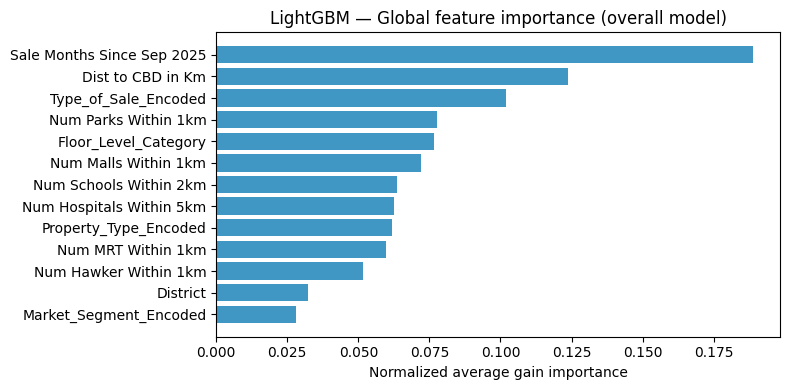

In [24]:
# LightGBM overall model with full-sample + CV metrics and feature importances
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

# ----------------- CONFIG -----------------
df_work = df.copy()   # your DataFrame (already in workspace)
target_col = 'Transacted Price ($)'

feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Schools Within 2km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded',
    'District'
]

# Keep only features found in df
feature_cols = [c for c in feature_cols if c in df_work.columns]
if len(feature_cols) == 0:
    raise ValueError("No feature columns found in df. Check feature_cols list.")

# Model / CV settings
N_FOLDS = 5
SEED = 42
MIN_ROWS = 50  # require at least this many rows to run model

lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'min_data_in_leaf': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'seed': SEED
}

# ----------------- PREPARE DATA -----------------
data = df_work[feature_cols + [target_col]].dropna().reset_index(drop=True)
n_rows = len(data)
print(f"Using {n_rows} rows and {len(feature_cols)} features for the overall LightGBM model.")

if n_rows < MIN_ROWS:
    raise ValueError(f"Insufficient rows ({n_rows}) after dropna. Need >= {MIN_ROWS} rows.")

X = data[feature_cols].astype(float)
y = data[target_col].astype(float).values

# safe MAPE (avoid division by zero)
def safe_mape(y_true, y_pred, eps=1e-6):
    y_true = np.maximum(np.asarray(y_true, dtype=float), eps)
    return mean_absolute_percentage_error(y_true, y_pred)

# ----------------- FULL-SAMPLE FIT (for reference) -----------------
dtrain_full = lgb.Dataset(X, label=y)
model_full = lgb.train(
    params=lgb_params,
    train_set=dtrain_full,
    num_boost_round=2000,
    valid_sets=[dtrain_full],
    callbacks=[lgb.log_evaluation(period=0)]
)
y_full_pred = model_full.predict(X, num_iteration=model_full.best_iteration)
full_r2 = r2_score(y, y_full_pred)
full_rmse = mean_squared_error(y, y_full_pred, squared=False)
full_mae = mean_absolute_error(y, y_full_pred)
full_mape = safe_mape(y, y_full_pred)

print("\n--- Full-sample metrics (training data) ---")
print(f"R² = {full_r2:.4f}, RMSE = {full_rmse:.2f}, MAE = {full_mae:.2f}, MAPE = {full_mape:.4f}")

# ----------------- K-FOLD CV -----------------
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

r2_folds = []
rmse_folds = []
mae_folds = []
mape_folds = []
fold_importances = pd.DataFrame(0, index=feature_cols, columns=range(N_FOLDS))

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    lgb_train = lgb.Dataset(X_train, label=y_train)
    lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)

    # callbacks for early stopping
    callbacks = [
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=0)
    ]

    model = lgb.train(
        params=lgb_params,
        train_set=lgb_train,
        num_boost_round=2000,
        valid_sets=[lgb_train, lgb_val],
        callbacks=callbacks
    )

    y_pred = model.predict(X_val, num_iteration=model.best_iteration)
    r2_folds.append(r2_score(y_val, y_pred))
    rmse_folds.append(mean_squared_error(y_val, y_pred, squared=False))
    mae_folds.append(mean_absolute_error(y_val, y_pred))
    mape_folds.append(safe_mape(y_val, y_pred))

    # store gain importances
    imp = model.feature_importance(importance_type='gain')
    fold_importances[fold] = pd.Series(imp, index=feature_cols)

# CV aggregates
cv_r2_mean, cv_r2_std = np.mean(r2_folds), np.std(r2_folds)
cv_rmse_mean, cv_rmse_std = np.mean(rmse_folds), np.std(rmse_folds)
cv_mae_mean, cv_mae_std = np.mean(mae_folds), np.std(mae_folds)
cv_mape_mean, cv_mape_std = np.mean(mape_folds), np.std(mape_folds)

print("\n--- Cross-validated metrics ({}-fold) ---".format(N_FOLDS))
print(f"R² mean ± std = {cv_r2_mean:.4f} ± {cv_r2_std:.4f}")
print(f"RMSE mean ± std = {cv_rmse_mean:.2f} ± {cv_rmse_std:.2f}")
print(f"MAE mean ± std = {cv_mae_mean:.2f} ± {cv_mae_std:.2f}")
print(f"MAPE mean ± std = {cv_mape_mean:.4f} ± {cv_mape_std:.4f}")

# ----------------- FEATURE IMPORTANCE (avg gain, normalized) -----------------
avg_imp = fold_importances.mean(axis=1)
if avg_imp.sum() > 0:
    avg_imp_norm = avg_imp / avg_imp.sum()
else:
    avg_imp_norm = avg_imp

imp_df = pd.DataFrame({
    'Feature': avg_imp_norm.index,
    'Avg_Importance_Gain': avg_imp_norm.values,
    'Raw_Avg_Gain': avg_imp.values
}).reset_index(drop=True).sort_values('Avg_Importance_Gain', ascending=False)

print("\nTop 10 features by average gain importance:")
print(imp_df.head(10).to_string(index=False))

# ----------------- SAVE OUTPUTS -----------------
imp_df.to_csv("lgb_overall_feature_importances.csv", index=False)

cv_summary = {
    'metric': ['r2','rmse','mae','mape'],
    'full_sample': [full_r2, full_rmse, full_mae, full_mape],
    'cv_mean': [cv_r2_mean, cv_rmse_mean, cv_mae_mean, cv_mape_mean],
    'cv_std': [cv_r2_std, cv_rmse_std, cv_mae_std, cv_mape_std]
}
cv_summary_df = pd.DataFrame(cv_summary)
cv_summary_df.to_csv("lgb_overall_cv_summary.csv", index=False)

print("\nSaved 'lgb_overall_feature_importances.csv' and 'lgb_overall_cv_summary.csv'.")

# ----------------- OPTIONAL: quick plot (bar) -----------------
import matplotlib.pyplot as plt
plt.figure(figsize=(8, max(4, 0.25 * len(imp_df))))
plt.barh(imp_df['Feature'][::-1], imp_df['Avg_Importance_Gain'][::-1], color='#2b8cbe', alpha=0.9)
plt.xlabel('Normalized average gain importance')
plt.title('LightGBM — Global feature importance (overall model)')
plt.tight_layout()
plt.show()


In [23]:
# --------- LightGBM per-district feature importance pipeline (with R²) ----------
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

# ---- Config ----
target_col = 'Transacted Price ($)'
district_col = 'District'

# Features to use (adjust if needed)
feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Schools Within 2km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded'
]

# Keep only existing features
feature_cols = [c for c in feature_cols if c in df.columns]

# Minimum rows per district to model
MIN_ROWS_PER_DISTRICT = 100

# Cross-validation folds
N_FOLDS = 5
SEED = 42

# LightGBM params (regression)
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'min_data_in_leaf': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'seed': SEED
}

# Containers for outputs
district_importances = []   # list of dicts per district with averaged importances
district_cv_scores = []     # RMSE and R2 per district (mean across folds)

# Iterate districts
districts = sorted(df[district_col].dropna().unique())

for dist in districts:
    df_dist = df[df[district_col] == dist].copy()
    n = len(df_dist)
    if n < MIN_ROWS_PER_DISTRICT:
        print(f"Skip District {dist}: only {n} rows (< {MIN_ROWS_PER_DISTRICT})")
        continue

    print(f"\nTraining District {dist} (n={n})")

    # Prepare data: drop rows with missing values in features or target
    data = df_dist[feature_cols + [target_col]].dropna()
    if data.shape[0] < MIN_ROWS_PER_DISTRICT:
        print(f"  After dropna: skip (insufficient rows: {data.shape[0]})")
        continue

    X = data[feature_cols].copy()
    y = data[target_col].astype(float).values

    # 5-fold CV
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_importances = pd.DataFrame(0, index=feature_cols, columns=range(N_FOLDS))
    rmse_folds = []
    r2_folds = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # LightGBM dataset
        lgb_train = lgb.Dataset(X_train, label=y_train)
        lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)

        # Use callbacks API for early stopping & logging
        callbacks = [
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=0)
        ]

        model = lgb.train(
            params=lgb_params,
            train_set=lgb_train,
            num_boost_round=2000,
            valid_sets=[lgb_train, lgb_val],
            callbacks=callbacks
        )

        # Predict & score
        y_pred = model.predict(X_val, num_iteration=model.best_iteration)
        rmse = mean_squared_error(y_val, y_pred, squared=False)
        r2 = r2_score(y_val, y_pred)

        rmse_folds.append(rmse)
        r2_folds.append(r2)

        # Feature importance (gain)
        imp = model.feature_importance(importance_type='gain')
        imp_series = pd.Series(imp, index=feature_cols)
        fold_importances[fold] = imp_series

    # Average importance across folds (and normalize to sum to 1)
    avg_imp = fold_importances.mean(axis=1)
    if avg_imp.sum() > 0:
        avg_imp_norm = avg_imp / avg_imp.sum()
    else:
        avg_imp_norm = avg_imp

    # Save results for the district
    imp_df = pd.DataFrame({
        'District': dist,
        'Feature': avg_imp_norm.index,
        'Avg_Importance_Gain': avg_imp_norm.values,
        'Raw_Avg_Gain': avg_imp.values
    }).reset_index(drop=True).sort_values('Avg_Importance_Gain', ascending=False)

    district_importances.append({
        'District': dist,
        'n': n,
        'rmse_mean': np.mean(rmse_folds) if rmse_folds else np.nan,
        'rmse_std': np.std(rmse_folds) if rmse_folds else np.nan,
        'r2_mean': np.mean(r2_folds) if r2_folds else np.nan,
        'r2_std': np.std(r2_folds) if r2_folds else np.nan,
        'imp_df': imp_df
    })

    # Also record summary CV scores
    district_cv_scores.append({
        'District': dist,
        'n': n,
        'RMSE_mean': np.mean(rmse_folds) if rmse_folds else np.nan,
        'RMSE_std': np.std(rmse_folds) if rmse_folds else np.nan,
        'R2_mean': np.mean(r2_folds) if r2_folds else np.nan,
        'R2_std': np.std(r2_folds) if r2_folds else np.nan
    })

    # Print top 5 features
    print("  Top 5 features (by avg gain):")
    for i, row in imp_df.head(5).iterrows():
        print(f"   - {row['Feature']}: {row['Avg_Importance_Gain']:.3f} (raw gain {row['Raw_Avg_Gain']:.1f})")
    print(f"  CV RMSE mean={np.mean(rmse_folds):.2f}, CV R² mean={np.mean(r2_folds):.3f}")

# --- Consolidate and save outputs ---
rows = []
for rec in district_importances:
    imp_df = rec['imp_df']
    for _, r in imp_df.iterrows():
        rows.append({
            'District': rec['District'],
            'n': rec['n'],
            'Feature': r['Feature'],
            'Avg_Importance_Gain': r['Avg_Importance_Gain'],
            'Raw_Avg_Gain': r['Raw_Avg_Gain'],
            'RMSE_mean': rec['rmse_mean'],
            'RMSE_std': rec['rmse_std'],
            'R2_mean': rec['r2_mean'],
            'R2_std': rec['r2_std']
        })

feat_importances_all = pd.DataFrame(rows)
feat_importances_all.to_csv("lgb_feature_importances_by_district.csv", index=False)

cv_scores_df = pd.DataFrame(district_cv_scores)
cv_scores_df.to_csv("lgb_cv_scores_by_district.csv", index=False)

print("\nSaved 'lgb_feature_importances_by_district.csv' and 'lgb_cv_scores_by_district.csv'.")

# --- Make a quick summary table: top feature per district (ranked by avg importance) ---
top_features = feat_importances_all.sort_values(['District','Avg_Importance_Gain'], ascending=[True, False]) \
                 .groupby('District').first().reset_index()[['District','Feature','Avg_Importance_Gain','n','RMSE_mean','R2_mean']]
top_features = top_features.sort_values('Avg_Importance_Gain', ascending=False)
print("\nTop feature by district (sample):")
print(top_features.head(10))



Training District 1 (n=1638)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[32]	training's rmse: 0.889932	valid_1's rmse: 0.624814
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[55]	training's rmse: 0.866477	valid_1's rmse: 0.675807
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[195]	training's rmse: 0.685943	valid_1's rmse: 1.08833
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[55]	training's rmse: 0.839961	valid_1's rmse: 0.750455
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[79]	training's rmse: 0.714683	valid_1's rmse: 1.13684
  Top 5 features (by avg gain):
   - Sale Months Since Sep 2025: 0.344 (raw gain 1542.7)
   - Floor_Level_Category: 0.221 (raw gain 990.0)
   - Dist to CBD in Km: 0.123 (raw gain 553.9)
   - Property_Type_Encode

KeyboardInterrupt: 

## Catboost

In [ ]:
pip install catboost

   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.5/102.4 MB 2.8 MB/s eta 0:00:37
    --------------------------------------- 1.8/102.4 MB 4.8 MB/s eta 0:00:21
   - -------------------------------------- 3.1/102.4 MB 5.4 MB/s eta 0:00:19
   - -------------------------------------- 4.2/102.4 MB 5.3 MB/s eta 0:00:19
   -- ------------------------------------- 5.5/102.4 MB 5.4 MB/s eta 0:00:18
   -- ------------------------------------- 6.8/102.4 MB 5.7 MB/s eta 0:00:17
   --- ------------------------------------ 8.4/102.4 MB 6.0 MB/s eta 0:00:16
   --- ------------------------------------ 9.2/102.4 MB 5.6 MB/s eta 0:00:17
   ---- ----------------------------------- 10.7/102.4 MB 5.7 MB/s eta 0:00:16
   ---- ----------------------------------- 12.1/102.4 MB 5.8 MB/s eta 0:00:16
   ----- ---------------------------------- 13.4/102.4 MB 5.9 MB/s eta 0:00:16
   ----- ---------------------------------- 14.4/102.4 MB 5.8 MB/s e

In [8]:
# CatBoost overall (whole-dataset) with full CV metrics + averaged feature importances
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from catboost import CatBoostRegressor, Pool
import warnings
warnings.filterwarnings("ignore")

# --- CONFIG ---
df_work = df.copy()  # your dataframe already loaded in the notebook
target_col = 'Transacted Price ($)'

feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Schools Within 2km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded'
]
# keep only existing features
feature_cols = [c for c in feature_cols if c in df_work.columns]

# CV & model params
N_FOLDS = 5
SEED = 42
MIN_ROWS = 50  # require minimal rows to run overall model

cat_params = {
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'iterations': 2000,
    'learning_rate': 0.05,
    'depth': 6,
    'l2_leaf_reg': 3,
    'random_seed': SEED,
    'logging_level': 'Silent',
    'early_stopping_rounds': 50
}

# --- sanity checks ---
if df_work.shape[0] < MIN_ROWS:
    raise ValueError(f"Not enough rows ({df_work.shape[0]}) to run the overall model (min {MIN_ROWS}).")

data = df_work[feature_cols + [target_col]].dropna().reset_index(drop=True)
if data.shape[0] < MIN_ROWS:
    raise ValueError(f"Not enough non-null rows after dropna ({data.shape[0]}).")

X = data[feature_cols].reset_index(drop=True)
y = data[target_col].astype(float).values

# Helper safe MAPE (avoid division by zero)
def safe_mape(y_true, y_pred, eps=1e-6):
    y_true = np.maximum(np.asarray(y_true, dtype=float), eps)
    return mean_absolute_percentage_error(y_true, y_pred)

# Containers for fold metrics & importances
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
rmse_folds = []
r2_folds = []
mae_folds = []
mape_folds = []
fold_importances = pd.DataFrame(0, index=feature_cols, columns=range(N_FOLDS))

print(f"Running {N_FOLDS}-fold CV on overall data (n = {len(y)}) with CatBoost...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    train_pool = Pool(X_train, y_train)
    val_pool = Pool(X_val, y_val)

    model = CatBoostRegressor(**cat_params)
    model.fit(train_pool, eval_set=val_pool, use_best_model=True)

    y_pred = model.predict(X_val)
    rmse = mean_squared_error(y_val, y_pred, squared=False)
    r2 = r2_score(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    mape = safe_mape(y_val, y_pred)

    rmse_folds.append(rmse)
    r2_folds.append(r2)
    mae_folds.append(mae)
    mape_folds.append(mape)

    # Feature importance (gain based on training pool)
    imp = model.get_feature_importance(train_pool)  # returns array aligned with feature_cols
    fold_importances[fold] = pd.Series(imp, index=feature_cols)

    print(f" Fold {fold+1}/{N_FOLDS}: RMSE={rmse:.2f}, R2={r2:.3f}, MAE={mae:.2f}, MAPE={mape:.4f}")

# Aggregate CV metrics
metrics_summary = {
    'RMSE_mean': np.mean(rmse_folds),
    'RMSE_std': np.std(rmse_folds),
    'R2_mean': np.mean(r2_folds),
    'R2_std': np.std(r2_folds),
    'MAE_mean': np.mean(mae_folds),
    'MAE_std': np.std(mae_folds),
    'MAPE_mean': np.mean(mape_folds),
    'MAPE_std': np.std(mape_folds),
    'n': len(y)
}

print("\n=== Cross-Validation Summary ===")
for k, v in metrics_summary.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

# Average & normalize importances across folds
avg_imp = fold_importances.mean(axis=1)
avg_imp_norm = avg_imp / avg_imp.sum() if avg_imp.sum() > 0 else avg_imp

imp_df = (
    pd.DataFrame({
        'Feature': avg_imp_norm.index,
        'Avg_Importance': avg_imp_norm.values,
        'Raw_Avg_Importance': avg_imp.values
    })
    .sort_values('Avg_Importance', ascending=False)
    .reset_index(drop=True)
)

# Save outputs
imp_df.to_csv("catboost_feature_importances_overall.csv", index=False)
pd.DataFrame([metrics_summary]).to_csv("catboost_cv_metrics_overall.csv", index=False)

# Print top features
print("\nTop 10 features by averaged importance (CatBoost):")
for i, r in imp_df.head(10).iterrows():
    print(f"  {i+1}. {r['Feature']}: {r['Avg_Importance']:.4f} (raw {r['Raw_Avg_Importance']:.2f})")

# Optional: train final model on full dataset (use best params & iterations from CV folds average)
final_pool = Pool(X, y)
final_model = CatBoostRegressor(**cat_params)
final_model.fit(final_pool, use_best_model=True)

# Save final model feature importance too
final_imp = final_model.get_feature_importance(final_pool)
final_imp_df = pd.DataFrame({'Feature': feature_cols, 'Final_Importance': final_imp}).sort_values('Final_Importance', ascending=False)
final_imp_df.to_csv("catboost_feature_importances_overall_final_model.csv", index=False)

print("\nSaved:")
print(" - catboost_feature_importances_overall.csv")
print(" - catboost_cv_metrics_overall.csv")
print(" - catboost_feature_importances_overall_final_model.csv")

# Short interpretation stub
print("\nQuick interpretation tips:")
print(" - Higher Avg_Importance means the feature contributes more (according to CatBoost) to predicting price.")
print(" - Use CV R2 and RMSE to judge predictive quality; also inspect MAE and MAPE for robust error measures.")


Running 5-fold CV on overall data (n = 108372) with CatBoost...
 Fold 1/5: RMSE=0.69, R2=0.446, MAE=0.47, MAPE=217159.4106
 Fold 2/5: RMSE=0.96, R2=0.312, MAE=0.47, MAPE=217196.7615
 Fold 3/5: RMSE=0.69, R2=0.452, MAE=0.47, MAPE=213479.0366
 Fold 4/5: RMSE=0.85, R2=0.340, MAE=0.48, MAPE=215678.7709
 Fold 5/5: RMSE=0.73, R2=0.419, MAE=0.48, MAPE=216680.8714

=== Cross-Validation Summary ===
  RMSE_mean: 0.7820
  RMSE_std: 0.1070
  R2_mean: 0.3936
  R2_std: 0.0571
  MAE_mean: 0.4748
  MAE_std: 0.0027
  MAPE_mean: 216038.9702
  MAPE_std: 1392.1859
  n: 108372

Top 10 features by averaged importance (CatBoost):
  1. Type_of_Sale_Encoded: 0.1569 (raw 15.69)
  2. Sale Months Since Sep 2025: 0.1335 (raw 13.35)
  3. Dist to CBD in Km: 0.1146 (raw 11.46)
  4. Property_Type_Encoded: 0.0904 (raw 9.04)
  5. Num Hospitals Within 5km: 0.0772 (raw 7.72)
  6. Num Malls Within 1km: 0.0751 (raw 7.51)
  7. Num Parks Within 1km: 0.0745 (raw 7.45)
  8. Num MRT Within 1km: 0.0678 (raw 6.78)
  9. Num Schools

You should provide test set for use best model. use_best_model parameter has been switched to false value.



Saved:
 - catboost_feature_importances_overall.csv
 - catboost_cv_metrics_overall.csv
 - catboost_feature_importances_overall_final_model.csv

Quick interpretation tips:
 - Higher Avg_Importance means the feature contributes more (according to CatBoost) to predicting price.
 - Use CV R2 and RMSE to judge predictive quality; also inspect MAE and MAPE for robust error measures.


In [18]:
# --- CatBoost per-district feature importance + full CV metrics pipeline ----------
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from catboost import CatBoostRegressor, Pool
import warnings
warnings.filterwarnings("ignore")

# ---- Config ----
target_col = 'Transacted Price ($)'
district_col = 'District'

# Feature list (same as LGBM pipeline)
feature_cols = [
    'Dist to CBD in Km',
    'Sale Months Since Sep 2025',
    'Num MRT Within 1km',
    'Num Schools Within 2km',
    'Num Hawker Within 1km',
    'Num Malls Within 1km',
    'Num Hospitals Within 5km',
    'Num Parks Within 1km',
    'Floor_Level_Category',
    'Type_of_Sale_Encoded',
    'Property_Type_Encoded',
    'Market_Segment_Encoded'
]
# keep only features that exist
feature_cols = [c for c in feature_cols if c in df.columns]

MIN_ROWS_PER_DISTRICT = 100
N_FOLDS = 5
SEED = 42

# CatBoost Parameters
cat_params = {
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'iterations': 1000,
    'learning_rate': 0.05,
    'depth': 8,
    'l2_leaf_reg': 3,
    'random_seed': SEED,
    'logging_level': 'Silent',
    'early_stopping_rounds': 50
}

# Containers for results
district_importances = []
district_cv_scores = []

# Helper: safe MAPE (avoid division by zero)
def safe_mape(y_true, y_pred, eps=1e-6):
    y_true = np.maximum(np.asarray(y_true, dtype=float), eps)
    return mean_absolute_percentage_error(y_true, y_pred)

# Loop through each district
districts = sorted(df[district_col].dropna().unique())

for dist in districts:
    df_dist = df[df[district_col] == dist].copy()
    n = len(df_dist)
    if n < MIN_ROWS_PER_DISTRICT:
        print(f"Skipping District {dist} — only {n} rows (< {MIN_ROWS_PER_DISTRICT})")
        continue

    print(f"\nTraining CatBoost for District {dist} (n={n})")

    # Drop missing values in selected columns
    data = df_dist[feature_cols + [target_col]].dropna()
    if data.shape[0] < MIN_ROWS_PER_DISTRICT:
        print(f"  After dropna: skip (insufficient rows: {data.shape[0]})")
        continue

    X = data[feature_cols].reset_index(drop=True)
    y = data[target_col].astype(float).values

    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    # per-fold metrics lists
    rmse_folds = []
    r2_folds = []
    mae_folds = []
    mape_folds = []
    fold_importances = pd.DataFrame(0, index=feature_cols, columns=range(N_FOLDS))

    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Pools
        train_pool = Pool(X_train, y_train)
        val_pool = Pool(X_val, y_val)

        model = CatBoostRegressor(**cat_params)
        model.fit(train_pool, eval_set=val_pool, use_best_model=True)

        y_pred = model.predict(X_val)
        rmse = mean_squared_error(y_val, y_pred, squared=False)
        r2 = r2_score(y_val, y_pred)
        mae = mean_absolute_error(y_val, y_pred)
        mape = safe_mape(y_val, y_pred)

        rmse_folds.append(rmse)
        r2_folds.append(r2)
        mae_folds.append(mae)
        mape_folds.append(mape)

        # Feature importance (gain) for this fold
        imp = model.get_feature_importance(train_pool)  # training-based importances
        fold_importances[fold] = pd.Series(imp, index=feature_cols)

    # Aggregate importances & normalize
    avg_imp = fold_importances.mean(axis=1)
    avg_imp_norm = avg_imp / avg_imp.sum() if avg_imp.sum() > 0 else avg_imp

    imp_df = (
        pd.DataFrame({
            'District': dist,
            'Feature': avg_imp_norm.index,
            'Avg_Importance': avg_imp_norm.values,
            'Raw_Importance': avg_imp.values
        })
        .sort_values('Avg_Importance', ascending=False)
        .reset_index(drop=True)
    )

    # CV metric summaries (mean, std)
    rmse_mean, rmse_std = (np.mean(rmse_folds), np.std(rmse_folds)) if rmse_folds else (np.nan, np.nan)
    r2_mean, r2_std = (np.mean(r2_folds), np.std(r2_folds)) if r2_folds else (np.nan, np.nan)
    mae_mean, mae_std = (np.mean(mae_folds), np.std(mae_folds)) if mae_folds else (np.nan, np.nan)
    mape_mean, mape_std = (np.mean(mape_folds), np.std(mape_folds)) if mape_folds else (np.nan, np.nan)

    # Save district summary
    district_importances.append({
        'District': dist,
        'n': n,
        'rmse_mean': rmse_mean,
        'rmse_std': rmse_std,
        'r2_mean': r2_mean,
        'r2_std': r2_std,
        'mae_mean': mae_mean,
        'mae_std': mae_std,
        'mape_mean': mape_mean,
        'mape_std': mape_std,
        'imp_df': imp_df
    })

    district_cv_scores.append({
        'District': dist,
        'n': n,
        'RMSE_mean': rmse_mean,
        'RMSE_std': rmse_std,
        'R2_mean': r2_mean,
        'R2_std': r2_std,
        'MAE_mean': mae_mean,
        'MAE_std': mae_std,
        'MAPE_mean': mape_mean,
        'MAPE_std': mape_std
    })

    # Display top 5 important features
    print(f"  CV RMSE mean={rmse_mean:.2f}, CV R² mean={r2_mean:.3f}")
    print("  Top 5 features:")
    for i, row in imp_df.head(5).iterrows():
        print(f"   - {row['Feature']}: {row['Avg_Importance']:.3f}")

# --- Consolidate all feature importances & CV scores to CSVs ---
rows = []
for rec in district_importances:
    imp_df = rec['imp_df']
    for _, r in imp_df.iterrows():
        rows.append({
            'District': rec['District'],
            'n': rec['n'],
            'Feature': r['Feature'],
            'Avg_Importance': r['Avg_Importance'],
            'Raw_Importance': r['Raw_Importance'],
            'RMSE_mean': rec['rmse_mean'],
            'RMSE_std': rec['rmse_std'],
            'R2_mean': rec['r2_mean'],
            'R2_std': rec['r2_std'],
            'MAE_mean': rec['mae_mean'],
            'MAE_std': rec['mae_std'],
            'MAPE_mean': rec['mape_mean'],
            'MAPE_std': rec['mape_std']
        })

feat_importances_all = pd.DataFrame(rows)
feat_importances_all.to_csv("catboost_feature_importances_by_district.csv", index=False)

cv_scores_df = pd.DataFrame(district_cv_scores)
cv_scores_df.to_csv("catboost_cv_scores_by_district.csv", index=False)

print("\nSaved 'catboost_feature_importances_by_district.csv' and 'catboost_cv_scores_by_district.csv'.")

# --- Quick summary: Top feature by district ---
top_features = (
    feat_importances_all.sort_values(['District', 'Avg_Importance'], ascending=[True, False])
    .groupby('District')
    .first()
    .reset_index()[['District', 'Feature', 'Avg_Importance', 'n', 'RMSE_mean', 'R2_mean']]
    .sort_values('Avg_Importance', ascending=False)
)
print("\nTop feature by district (sample):")
print(top_features.head(10))



Training CatBoost for District 1 (n=1638)
  CV RMSE mean=0.85, CV R² mean=0.245
  Top 5 features:
   - Floor_Level_Category: 0.268
   - Sale Months Since Sep 2025: 0.231
   - Property_Type_Encoded: 0.144
   - Num MRT Within 1km: 0.080
   - Num Hawker Within 1km: 0.059

Training CatBoost for District 2 (n=1207)
  CV RMSE mean=0.65, CV R² mean=0.501
  Top 5 features:
   - Floor_Level_Category: 0.370
   - Sale Months Since Sep 2025: 0.301
   - Type_of_Sale_Encoded: 0.070
   - Dist to CBD in Km: 0.065
   - Num MRT Within 1km: 0.050

Training CatBoost for District 3 (n=4625)
  CV RMSE mean=0.73, CV R² mean=0.482
  Top 5 features:
   - Floor_Level_Category: 0.211
   - Sale Months Since Sep 2025: 0.205
   - Dist to CBD in Km: 0.127
   - Num Schools Within 2km: 0.085
   - Num Hospitals Within 5km: 0.080

Training CatBoost for District 4 (n=2112)
  CV RMSE mean=0.71, CV R² mean=0.501
  Top 5 features:
   - Dist to CBD in Km: 0.240
   - Num Hawker Within 1km: 0.211
   - Sale Months Since Sep 20

In [21]:
pip install shap

   ---------------------------------------- 0.0/548.0 kB ? eta -:--:--
   --------------------------------------- 548.0/548.0 kB 17.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


Data: 108372 rows, 13 features
Using existing 'final_model' from workspace.
Using sample_frac=0.3 -> 32512 rows for SHAP calculation.
SHAP values shape: (32512, 13)
Saved SHAP ranking to catboost_shap_overall_mean_abs_shap_ranking.csv


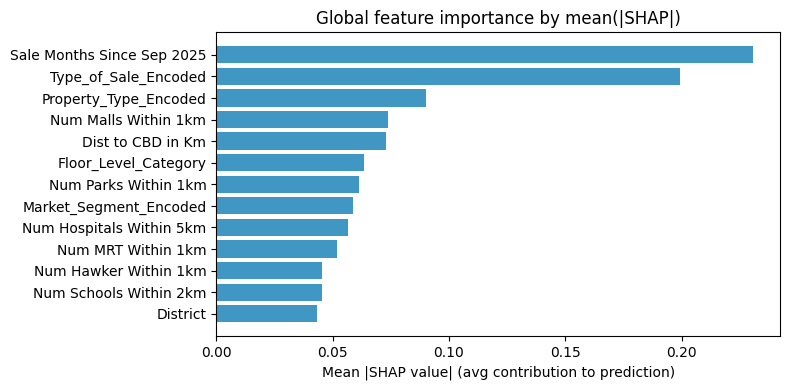

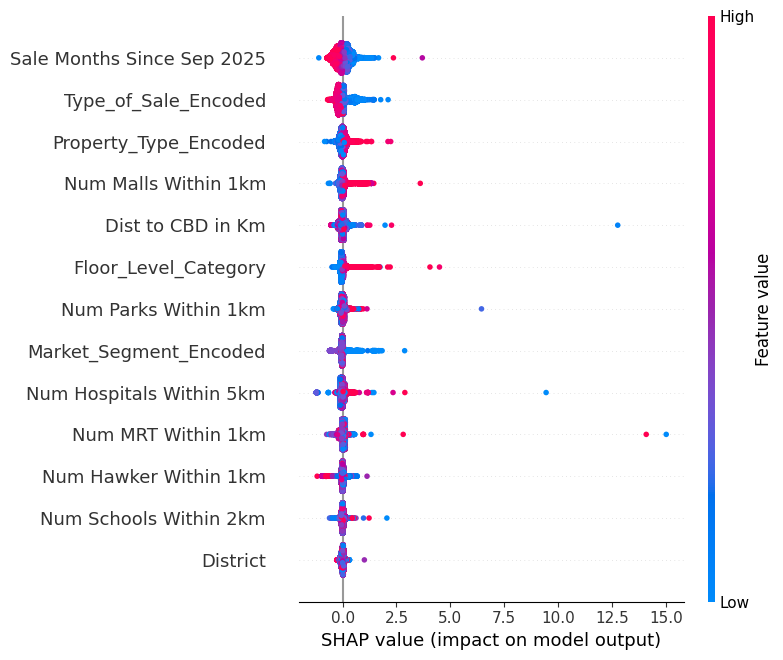

<Figure size 640x480 with 0 Axes>

<Figure size 600x300 with 0 Axes>

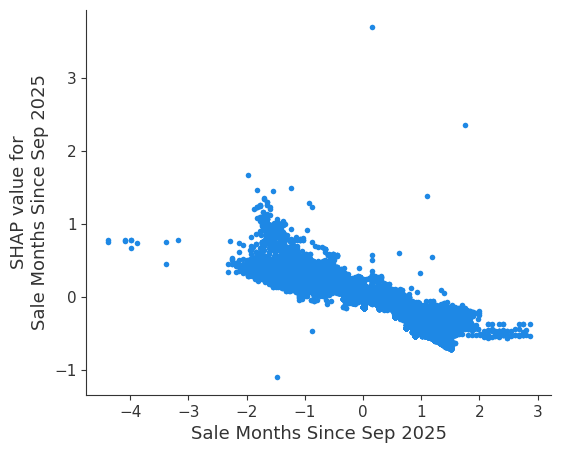

<Figure size 640x480 with 0 Axes>

<Figure size 600x300 with 0 Axes>

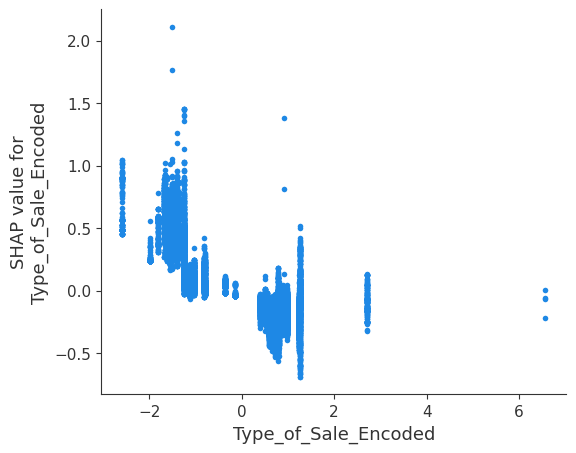

<Figure size 640x480 with 0 Axes>

<Figure size 600x300 with 0 Axes>

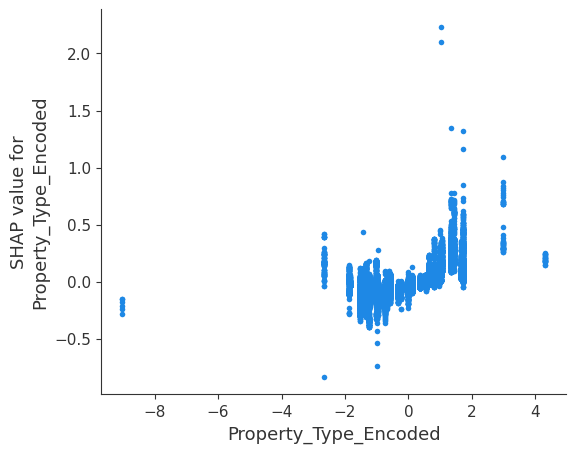

<Figure size 640x480 with 0 Axes>

<Figure size 600x300 with 0 Axes>

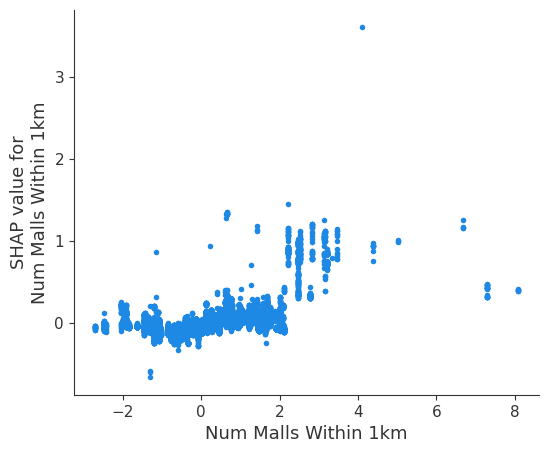

<Figure size 640x480 with 0 Axes>

<Figure size 600x300 with 0 Axes>

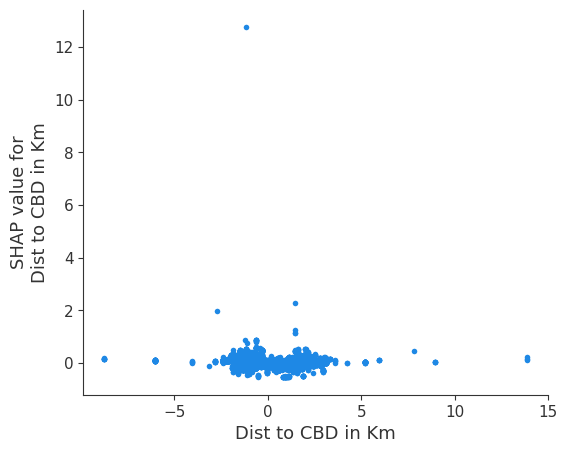

<Figure size 640x480 with 0 Axes>

<Figure size 600x300 with 0 Axes>

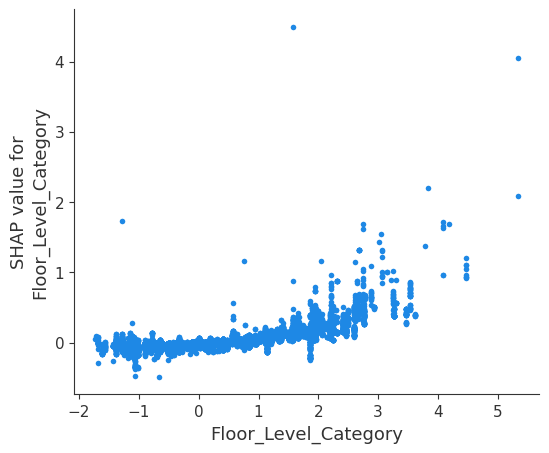


Top features by mean(|SHAP|):
                   Feature  MeanAbsSHAP  Share
Sale Months Since Sep 2025       0.2307 0.2111
      Type_of_Sale_Encoded       0.1992 0.1823
     Property_Type_Encoded       0.0902 0.0825
      Num Malls Within 1km       0.0739 0.0676
         Dist to CBD in Km       0.0731 0.0669
      Floor_Level_Category       0.0635 0.0581
      Num Parks Within 1km       0.0612 0.0560
    Market_Segment_Encoded       0.0586 0.0536
  Num Hospitals Within 5km       0.0565 0.0517
        Num MRT Within 1km       0.0519 0.0475
     Num Hawker Within 1km       0.0455 0.0416
    Num Schools Within 2km       0.0454 0.0415


<Figure size 640x480 with 0 Axes>

In [22]:
# ---------- SHAP-based feature ranking for CatBoost (overall dataset) ----------
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor, Pool

# config (adjust if needed)
feature_cols = [c for c in feature_cols if c in df_work.columns]  # reuse from previous cell if present
target_col = 'Transacted Price ($)'
sample_frac = 0.3        # fraction of data to use for SHAP computations (set to 1.0 to use all)
random_state = 42
save_prefix = "catboost_shap_overall"

# --- Prepare dataset (dropna on chosen columns) ---
data = df_work[feature_cols + [target_col]].dropna().reset_index(drop=True)
X = data[feature_cols].copy()
y = data[target_col].astype(float).values
n = len(X)
print(f"Data: {n} rows, {len(feature_cols)} features")

if n == 0:
    raise ValueError("No rows available after dropna. Check your dataframe and selected features.")

# --- Train final model if not available (or you can reuse an existing trained model) ---
# If you have `final_model` loaded from before, comment out the training lines below and
# ensure `final_model` exists.
cat_params_local = {
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'iterations': 2000,
    'learning_rate': 0.05,
    'depth': 6,
    'l2_leaf_reg': 3,
    'random_seed': random_state,
    'logging_level': 'Silent',
    'early_stopping_rounds': 50
}

try:
    final_model  # reuse if exists
    print("Using existing 'final_model' from workspace.")
except NameError:
    print("Training final CatBoost model on full dataset (this may take some time)...")
    pool = Pool(X, y)
    final_model = CatBoostRegressor(**cat_params_local)
    final_model.fit(pool, use_best_model=True)
    print("Model trained.")

# --- Create SHAP explainer & compute SHAP values ---
# For tree models, TreeExplainer is appropriate
explainer = shap.TreeExplainer(final_model)

# If dataset large, compute SHAP on a subsample for speed & memory
if 0 < sample_frac < 1.0:
    X_sample = X.sample(frac=sample_frac, random_state=random_state).reset_index(drop=True)
    print(f"Using sample_frac={sample_frac} -> {len(X_sample)} rows for SHAP calculation.")
else:
    X_sample = X.copy()
    print("Computing SHAP on full dataset.")

# Convert to numpy or DataFrame; TreeExplainer accepts DataFrame
shap_values = explainer.shap_values(X_sample)  # shape (n_samples, n_features) for regression
# Note: for some CatBoost versions shap_values returns list; ensure shape correct:
if isinstance(shap_values, list):
    # for regresion this shouldn't be list, but if multi-output returns list; handle by selecting first
    shap_values = np.array(shap_values).squeeze()
shap_values = np.asarray(shap_values)

print("SHAP values shape:", shap_values.shape)

# --- Compute global importance: mean absolute SHAP per feature ---
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
shap_ranking = pd.DataFrame({
    'Feature': X_sample.columns,
    'MeanAbsSHAP': mean_abs_shap
}).sort_values('MeanAbsSHAP', ascending=False).reset_index(drop=True)

# normalize score (optional)
shap_ranking['Share'] = shap_ranking['MeanAbsSHAP'] / shap_ranking['MeanAbsSHAP'].sum()

# save ranking
shap_ranking.to_csv(f"{save_prefix}_mean_abs_shap_ranking.csv", index=False)
print(f"Saved SHAP ranking to {save_prefix}_mean_abs_shap_ranking.csv")

# --- Plot horizontal bar chart of mean(|SHAP|) ---
plt.figure(figsize=(8, max(4, 0.3 * len(shap_ranking))))
plt.barh(shap_ranking['Feature'][::-1], shap_ranking['MeanAbsSHAP'][::-1], color='#2b8cbe', alpha=0.9)
plt.xlabel('Mean |SHAP value| (avg contribution to prediction)')
plt.title('Global feature importance by mean(|SHAP|)')
plt.tight_layout()
plt.savefig(f"{save_prefix}_bar.png", dpi=200)
plt.show()

# --- SHAP summary plot (beeswarm) ---
# Use the same sample used for SHAP calculations
# summary_plot uses matplotlib; if running in headless env you may need to set backend
shap.summary_plot(shap_values, X_sample, show=True)
plt.savefig(f"{save_prefix}_summary.png", dpi=300, bbox_inches='tight')

# --- Optional: show top-k feature dependence plots for interpretation ---
top_k = 6
top_features = shap_ranking['Feature'].head(top_k).tolist()
for feat in top_features:
    plt.figure(figsize=(6,3))
    shap.dependence_plot(feat, shap_values, X_sample, show=True, interaction_index=None)  # set interaction_index to see interactions
    plt.tight_layout()
    plt.savefig(f"{save_prefix}_dependence_{feat}.png", dpi=200)

print("\nTop features by mean(|SHAP|):")
print(shap_ranking.head(12).to_string(index=False))
